In [156]:
import pandas as pd
import geopandas as gp
import os
import pber_functions_v1 as pber
from collections import Counter

In [157]:
tx_24_vtd_shp = gp.read_file("./raw-from-source/vtds_24pg/VTDs_24PG.shp")

In [158]:
tx_24_vtd_shp

,CNTY,COLOR,VTD,CNTYKEY,VTDKEY,CNTYVTD,Shape_area,Shape_len,geometry
0,1,4,0001,1,1.0,10001,5.666216e+06,15288.088777,"POLYGON ((1413960.808 1073012.816, 1413971.571..."
1,1,3,0002,1,2.0,10002,2.562129e+08,94434.420881,"POLYGON ((1420165.429 1066385.798, 1420251.968..."
2,1,6,0003,1,3.0,10003,7.072228e+07,55660.372406,"POLYGON ((1416579.790 1072023.104, 1416744.635..."
3,1,2,0004,1,4.0,10004,2.410662e+08,91319.549282,"POLYGON ((1435674.876 1074608.545, 1435714.039..."
4,1,1,0005,1,5.0,10005,1.689854e+08,86937.648556,"POLYGON ((1436888.342 1072498.734, 1436911.364..."
...,...,...,...,...,...,...,...,...,...
9707,507,2,0002,254,9708.0,2540002,1.144179e+07,18114.070807,"POLYGON ((1019974.802 725691.591, 1019975.499 ..."
9708,507,1,0003,254,9709.0,2540003,5.340784e+07,38006.459232,"POLYGON ((1015599.850 726010.282, 1015617.011 ..."
9709,507,5,0004,254,9710.0,2540004,8.136344e+08,135078.118211,"POLYGON ((1012797.112 770079.540, 1012756.534 ..."
9710,507,4,001A,254,9711.0,254001A,5.517531e+08,114986.207245,"POLYGON ((1038701.220 746222.309, 1038691.418 ..."


In [159]:
path = "./raw-from-source/2024-general-vtds-election-data/"

file_holder = []

for file in os.listdir(path):
    if file[0:4] == "2024" and "_VRTO" not in file:
        temp_holder = pd.read_csv(path + file)
        temp_holder["year"] = file[0:4]
        election_type = file.split("_")[2]
        print(election_type)
        temp_holder["election_type"]= election_type
        if election_type in ["Election"]:
            print(file)
            temp_holder["cand_detailed"] = temp_holder["election_type"]+"-:-"+temp_holder["year"]+"-:-"+temp_holder["Office"]+"-:-"+temp_holder["Party"]+"-:-"+temp_holder["Name"]
            temp_holder["mod_vtd"] = temp_holder["FIPS"].astype(str).str.zfill(3) + "-" + temp_holder["VTD"].astype(str)
            temp_holder_pivoted = pd.pivot_table(temp_holder, values=['Votes'], index=["mod_vtd", "County", "FIPS"],columns=["cand_detailed"],aggfunc=sum)
            temp_holder_pivoted.columns = temp_holder_pivoted.columns.droplevel(0)

            file_holder.append(temp_holder_pivoted)

Dist
Dist
Primary
Primary
Runoff
Election
2024_General_Election_Returns.csv


/var/folders/1t/0q4w6hm92mg_zxd84dfxmq3m0000gn/T/ipykernel_26054/926822890.py:16: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  temp_holder_pivoted = pd.pivot_table(temp_holder, values=['Votes'], index=["mod_vtd", "County", "FIPS"],columns=["cand_detailed"],aggfunc=sum)


Runoff
Dist
District


In [160]:
# Combine the files together
joined = pd.concat(file_holder, axis = 1)
joined.reset_index(inplace = True, drop = False)

# Get the race to filter down to appropriate columns
col_name_list = [i.split("-:-")[2] for i in joined.columns if i not in ["mod_vtd", "County", "FIPS"]]

In [161]:
max(joined[joined['Election-:-2024-:-RR Comm 1-:-W-:-McKibbin']>0][["mod_vtd",'Election-:-2024-:-RR Comm 1-:-W-:-McKibbin']]['Election-:-2024-:-RR Comm 1-:-W-:-McKibbin'])

11.0

In [162]:
# Filter down to the relevant state races
keep_races =  [i for i in set(col_name_list) if 'President' in i or "U.S. Sen" in i
 or 'Governor' in i or 'Lt. Governor' in i or 'Attorney Gen' in i or 'Comptroller' in i
  or 'Ag Comm' in i or 'Land Comm' in i  or 'RR Comm' in i or 'Sup Ct' in i or 'CCA' in i
    or 'U.S. Rep' in i or 'State Rep' in i or 'State Sen' in i]

In [163]:
not_including = [i for i in col_name_list if i not in keep_races]
not_including.sort()
print(not_including)

['11th District Judge', '11th District Judge', '129th District Judge', '129th District Judge', '133rd District Judge', '133rd District Judge', '164th District Judge', '164th District Judge', '165th District Judge', '165th District Judge', '177th District Judge', '177th District Judge', '19th District Judge', '19th District Judge', '213th District Judge', '213th District Judge', '214th District Judge', '214th District Judge', '215th District Judge', '215th District Judge', '28th District Judge', '28th District Judge', '333rd District Judge', '333rd District Judge', '338th District Judge', '338th District Judge', '400th District Judge', '400th District Judge', '486th District Judge', '486th District Judge', '487th District Judge', '487th District Judge', '488th District Judge', '488th District Judge', '507th District Judge', '507th District Judge', '61st District Judge', '61st District Judge', '80th District Judge', '80th District Judge', 'Bell County Attorney', 'Bell County Attorney', '

In [164]:
# Filter the df down to the relevant columns
keep_races.sort()
keep_names = ["mod_vtd", "County", "FIPS"]
col_names_keep = [i for i in joined.columns if i not in keep_names and i.split("-:-")[2] in keep_races]
joined = joined[keep_names + col_names_keep]

In [165]:
joined

cand_detailed,mod_vtd,County,FIPS,Election-:-2024-:-CCA 7-:-D-:-Mulder,Election-:-2024-:-CCA 7-:-R-:-Parker,Election-:-2024-:-CCA 8-:-D-:-Anyiam,Election-:-2024-:-CCA 8-:-R-:-Finley,Election-:-2024-:-CCA Pres Judge-:-D-:-Taylor,Election-:-2024-:-CCA Pres Judge-:-R-:-Schenck,Election-:-2024-:-President-:-D-:-Harris,...,Election-:-2024-:-U.S. Rep 6-:-R-:-Ellzey,Election-:-2024-:-U.S. Rep 7-:-D-:-Fletcher,Election-:-2024-:-U.S. Rep 7-:-R-:-Kane,Election-:-2024-:-U.S. Rep 8-:-D-:-Jones,Election-:-2024-:-U.S. Rep 8-:-R-:-Luttrell,Election-:-2024-:-U.S. Sen-:-D-:-Allred,Election-:-2024-:-U.S. Sen-:-L-:-Brown,Election-:-2024-:-U.S. Sen-:-R-:-Cruz,Election-:-2024-:-U.S. Sen-:-W-:-Andrus,Election-:-2024-:-U.S. Sen-:-W-:-Roche
0,001-0001,Anderson,1,302.0,757.0,299.0,758.0,310.0,751.0,325.0,...,773.0,NaN,NaN,NaN,NaN,330.0,25.0,742.0,0.0,0.0
1,001-0002,Anderson,1,183.0,1612.0,178.0,1617.0,197.0,1605.0,182.0,...,1631.0,NaN,NaN,NaN,NaN,215.0,25.0,1620.0,0.0,0.0
2,001-0003,Anderson,1,101.0,713.0,94.0,716.0,109.0,708.0,110.0,...,731.0,NaN,NaN,NaN,NaN,124.0,21.0,712.0,0.0,0.0
3,001-0004,Anderson,1,116.0,1034.0,106.0,1045.0,117.0,1039.0,109.0,...,1061.0,NaN,NaN,NaN,NaN,135.0,18.0,1032.0,0.0,0.0
4,001-0005,Anderson,1,15.0,199.0,16.0,198.0,17.0,198.0,17.0,...,202.0,NaN,NaN,NaN,NaN,19.0,6.0,198.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,507-0002,Zavala,507,483.0,245.0,484.0,246.0,501.0,240.0,562.0,...,NaN,NaN,NaN,NaN,NaN,575.0,18.0,276.0,0.0,0.0
9708,507-0003,Zavala,507,472.0,202.0,465.0,210.0,492.0,196.0,556.0,...,NaN,NaN,NaN,NaN,NaN,545.0,31.0,226.0,0.0,0.0
9709,507-0004,Zavala,507,238.0,257.0,244.0,260.0,265.0,251.0,283.0,...,NaN,NaN,NaN,NaN,NaN,292.0,27.0,298.0,0.0,0.0
9710,507-001A,Zavala,507,236.0,153.0,239.0,151.0,244.0,155.0,253.0,...,NaN,NaN,NaN,NaN,NaN,253.0,20.0,156.0,0.0,0.0


In [166]:
def get_election_type(contest):
    first = contest.split("-:-")[0]
    if first == 'Election':
        e_type = "G"
    elif first == "District" or first == "Dist":
        e_type = "S"
    elif first == 'Runoff':
        e_type = "R"
    elif first == 'Primary':
        e_type = "P"
    else:
        print(contest)
        raise ValueError
    return e_type

def get_race(contest):
    mod_level = ""
    level = contest.split("-:-")[2]
    level_change_dict = {
        'President':'PRE',
        "U.S. Sen":'USS',
        'Governor':'GOV',
        'Lt. Governor':'LTG',
        'Attorney Gen':'ATG',
        'Comptroller':'COM',
        'Ag Comm':'AGR',
        'Land Comm':'LAN',
        'RR Comm':'RRC',
        'Sup Ct':'SSC',
        'CCA':'CCA',
        'U.S. Rep':'CON',
        'State Sen':'SU',
        'State Rep':'SL'}
    for val in level_change_dict.keys():
        if val in level:
            mod_level = level_change_dict[val]
    if mod_level == "":
        print(contest)
    if mod_level in ['RRC', 'CCA', 'SSC', "CON", "SU", "SL"]:
            dist_num = str(level.split(" ")[-1])
            print(dist_num)
            if dist_num == "Chief":
                dist_num = 'C'
            elif dist_num == "Judge":
                dist_num = 'P'
            if mod_level == "SL":
                fill = 3
            elif mod_level == "CCA":
                fill = 1
            else:
                fill = 2
            mod_level += str(dist_num).zfill(fill)
    return mod_level

def get_party(contest):
    party = contest.split("-:-")[3]
    if party == "W":
        return "O"
    else:
        return party
    
def get_name(contest):
    candidate = contest.split("-:-")[4]
    candidate = candidate.upper()
    candidate = candidate.replace(" ", "")
    likely_last = candidate.split(" ")[-1]
    return likely_last[0:3]

In [167]:
contest_name_change_dict = {}

duplicate_value_list = []
for contest in joined.columns:
    if contest not in keep_names:
        print(contest)
        
        # Add in a condition about the 20
        if "CCA" in contest or "Sup Ct" in contest or "RR Comm" in contest or 'U.S. Rep' in contest or 'State Sen' in contest or 'State Rep' in contest:
            value = get_election_type(contest) + get_race(contest)+ get_party(contest)+ get_name(contest)
            if value in contest_name_change_dict.values():
                duplicate_value_list.append(value)
            contest_name_change_dict[contest] = value 
        else:
            value = get_election_type(contest) + "24" + get_race(contest)+ get_party(contest)+ get_name(contest)
            if value in contest_name_change_dict.values():
                duplicate_value_list.append(value)
            contest_name_change_dict[contest] = value 

if len(duplicate_value_list) > 0:
    print("DUPLICATE VALUES")
    for val in [(k,v) for k, v in contest_name_change_dict.items() if v in duplicate_value_list]:
        print(val)

Election-:-2024-:-CCA 7-:-D-:-Mulder
7
Election-:-2024-:-CCA 7-:-R-:-Parker
7
Election-:-2024-:-CCA 8-:-D-:-Anyiam
8
Election-:-2024-:-CCA 8-:-R-:-Finley
8
Election-:-2024-:-CCA Pres Judge-:-D-:-Taylor
Judge
Election-:-2024-:-CCA Pres Judge-:-R-:-Schenck
Judge
Election-:-2024-:-President-:-D-:-Harris
Election-:-2024-:-President-:-G-:-Stein
Election-:-2024-:-President-:-L-:-Oliver
Election-:-2024-:-President-:-R-:-Trump
Election-:-2024-:-President-:-W-:-Write-In
Election-:-2024-:-RR Comm 1-:-D-:-Culbert
1
Election-:-2024-:-RR Comm 1-:-G-:-Espinoza
1
Election-:-2024-:-RR Comm 1-:-L-:-Dunlap
1
Election-:-2024-:-RR Comm 1-:-R-:-Craddick
1
Election-:-2024-:-RR Comm 1-:-W-:-McKibbin
1
Election-:-2024-:-State Rep 10-:-R-:-Harrison
10
Election-:-2024-:-State Rep 10-:-W-:-Brummell
10
Election-:-2024-:-State Rep 10-:-W-:-Schroppel
10
Election-:-2024-:-State Rep 101-:-D-:-Turner
101
Election-:-2024-:-State Rep 101-:-R-:-Burgess
101
Election-:-2024-:-State Rep 105-:-D-:-Meza
105
Election-:-2024-:-

In [168]:
df = pd.DataFrame([(v, k.split("-:-")[4]) for k, v in contest_name_change_dict.items()], columns=['Candidate', 'Column'])
# # Store the data into a csv file
df.sort_values('Candidate', inplace = True)
df.to_csv('./field_names.csv', sep=',')

In [169]:
pd.DataFrame(contest_name_change_dict.items()).to_csv("./field_names.csv", index = False)

## Add COUNTYFP

In [170]:
joined["COUNTYFP"] = joined["FIPS"].astype(str).str.zfill(3)

In [171]:
county_dict = dict(zip(joined["County"].str.upper(), joined["FIPS"].astype(str).str.zfill(3)))

Join to shapefile

In [172]:
tx_24_vtd_shp['mod_vtd'] = tx_24_vtd_shp['CNTY'].astype(str).str.zfill(3)+"-"+tx_24_vtd_shp['VTD'].astype(str)

In [173]:
joined["mod_vtd"] = joined["mod_vtd"].str.upper()

In [174]:
tx_24_vtd_comb = gp.GeoDataFrame(pd.merge(joined, tx_24_vtd_shp, how = "outer", on = "mod_vtd", indicator = True))
tx_24_vtd_comb["_merge"].value_counts()

_merge
both          9712
left_only        0
right_only       0
Name: count, dtype: int64

## Clean columns

In [175]:
tx_24_vtd_comb["UNIQUE_ID"] = tx_24_vtd_comb["mod_vtd"]

In [176]:
sorted_cands = {k: v for k, v in sorted(contest_name_change_dict.items(), key=lambda item: item[1])}

In [177]:
sorted_cands

{'Election-:-2024-:-President-:-D-:-Harris': 'G24PREDHAR',
 'Election-:-2024-:-President-:-G-:-Stein': 'G24PREGSTE',
 'Election-:-2024-:-President-:-L-:-Oliver': 'G24PRELOLI',
 'Election-:-2024-:-President-:-W-:-Write-In': 'G24PREOWRI',
 'Election-:-2024-:-President-:-R-:-Trump': 'G24PRERTRU',
 'Election-:-2024-:-U.S. Sen-:-D-:-Allred': 'G24USSDALL',
 'Election-:-2024-:-U.S. Sen-:-L-:-Brown': 'G24USSLBRO',
 'Election-:-2024-:-U.S. Sen-:-W-:-Andrus': 'G24USSOAND',
 'Election-:-2024-:-U.S. Sen-:-W-:-Roche': 'G24USSOROC',
 'Election-:-2024-:-U.S. Sen-:-R-:-Cruz': 'G24USSRCRU',
 'Election-:-2024-:-CCA 7-:-D-:-Mulder': 'GCCA7DMUL',
 'Election-:-2024-:-CCA 7-:-R-:-Parker': 'GCCA7RPAR',
 'Election-:-2024-:-CCA 8-:-D-:-Anyiam': 'GCCA8DANY',
 'Election-:-2024-:-CCA 8-:-R-:-Finley': 'GCCA8RFIN',
 'Election-:-2024-:-CCA Pres Judge-:-D-:-Taylor': 'GCCAPDTAY',
 'Election-:-2024-:-CCA Pres Judge-:-R-:-Schenck': 'GCCAPRSCH',
 'Election-:-2024-:-U.S. Rep 2-:-D-:-Filler': 'GCON02DFIL',
 'Election-:-202

In [178]:
list(sorted_cands.values())

['G24PREDHAR',
 'G24PREGSTE',
 'G24PRELOLI',
 'G24PREOWRI',
 'G24PRERTRU',
 'G24USSDALL',
 'G24USSLBRO',
 'G24USSOAND',
 'G24USSOROC',
 'G24USSRCRU',
 'GCCA7DMUL',
 'GCCA7RPAR',
 'GCCA8DANY',
 'GCCA8RFIN',
 'GCCAPDTAY',
 'GCCAPRSCH',
 'GCON02DFIL',
 'GCON02RCRE',
 'GCON03DSRI',
 'GCON03RSEL',
 'GCON04DCAR',
 'GCON04RFAL',
 'GCON05DTOR',
 'GCON05RGOO',
 'GCON06DLOV',
 'GCON06RELL',
 'GCON07DFLE',
 'GCON07RKAN',
 'GCON08DJON',
 'GCON08RLUT',
 'GCON10DBOI',
 'GCON10LMIL',
 'GCON10RMCC',
 'GCON12DHUN',
 'GCON12RGOL',
 'GCON14DHAR',
 'GCON14RWEB',
 'GCON15DVAL',
 'GCON15RDEL',
 'GCON16DESC',
 'GCON16OMON',
 'GCON16RARM',
 'GCON17DLOR',
 'GCON17RSES',
 'GCON18DTUR',
 'GCON18ODUN',
 'GCON18ODUR',
 'GCON18RCEN',
 'GCON19ILEW',
 'GCON19LJOH',
 'GCON19RARR',
 'GCON21DHOO',
 'GCON21LKIN',
 'GCON21RROY',
 'GCON22DGRE',
 'GCON22RNEH',
 'GCON23DLIM',
 'GCON23RGON',
 'GCON24DEPP',
 'GCON24RVAN',
 'GCON25OHAG',
 'GCON25RWIL',
 'GCON26DLIN',
 'GCON26LGRA',
 'GCON26RGIL',
 'GCON27DLLO',
 'GCON27RCLO',
 

In [179]:
tx_24_vtd_comb.rename(columns = contest_name_change_dict, inplace = True)

In [180]:
tx_24_vtd_comb = tx_24_vtd_comb[["UNIQUE_ID","COUNTYFP","County","VTD"]+list(sorted_cands.values()) + ["geometry"]]

In [181]:
tx_24_vtd_comb = tx_24_vtd_comb.fillna(0)
for val in list(sorted_cands.values()):
    tx_24_vtd_comb[val] = tx_24_vtd_comb[val].astype(int)
    #print(val, sum(tx_24_vtd_comb[val]))

In [182]:
## Read in totals to compare against

totals = pd.read_csv("./raw-from-source/CountybyCountyCanvassReport.csv")
#totals = pd.read_csv("./raw-from-source/OfficialCanvassReport.csv")

In [183]:
totals = totals.astype(str).replace("\n","")

In [184]:
totals.rename(columns = {i :i.replace("\n","").strip() for i in list(totals.columns)}, inplace = True)

In [185]:
for col in list(totals.columns):
    totals[col] = totals[col].astype(str).str.replace("\n","").str.strip()

In [186]:
totals.columns

Index(['ELECTION DATE-NAME', 'OFFICE NAME', 'CANDIDATE NAME', 'COUNTY NAME',
       'TOTAL VOTES PER OFFICE PER COUNTY'],
      dtype='object')

In [187]:
totals["TOTAL VOTES PER OFFICE PER COUNTY"] = totals["TOTAL VOTES PER OFFICE PER COUNTY"].astype(str).str.replace(",","").astype(int)
#totals["CANVASS VOTES"] = totals["CANVASS VOTES"].astype(str).str.replace(",","").astype(int)

In [188]:
totals["pivot_col"] = totals["OFFICE NAME"] + "-:-" + totals["CANDIDATE NAME"]

In [189]:
totals["OFFICE NAME"].unique()

array(['PRESIDENT/VICE-PRESIDENT', 'U. S. SENATOR',
       'U. S. REPRESENTATIVE DISTRICT 1',
       'U. S. REPRESENTATIVE DISTRICT 2',
       'U. S. REPRESENTATIVE DISTRICT 3',
       'U. S. REPRESENTATIVE DISTRICT 4',
       'U. S. REPRESENTATIVE DISTRICT 5',
       'U. S. REPRESENTATIVE DISTRICT 6',
       'U. S. REPRESENTATIVE DISTRICT 7',
       'U. S. REPRESENTATIVE DISTRICT 8',
       'U. S. REPRESENTATIVE DISTRICT 9',
       'U. S. REPRESENTATIVE DISTRICT 10',
       'U. S. REPRESENTATIVE DISTRICT 11',
       'U. S. REPRESENTATIVE DISTRICT 12',
       'U. S. REPRESENTATIVE DISTRICT 13',
       'U. S. REPRESENTATIVE DISTRICT 14',
       'U. S. REPRESENTATIVE DISTRICT 15',
       'U. S. REPRESENTATIVE DISTRICT 16',
       'U. S. REPRESENTATIVE DISTRICT 17',
       'U. S. REPRESENTATIVE DISTRICT 18',
       'U. S. REPRESENTATIVE DISTRICT 19',
       'U. S. REPRESENTATIVE DISTRICT 20',
       'U. S. REPRESENTATIVE DISTRICT 21',
       'U. S. REPRESENTATIVE DISTRICT 22',
       'U. 

In [190]:
col_list = ['PRESIDENT/VICE-PRESIDENT', 'U. S. SENATOR',
       'U. S. REPRESENTATIVE DISTRICT 1',
       'U. S. REPRESENTATIVE DISTRICT 2',
       'U. S. REPRESENTATIVE DISTRICT 3',
       'U. S. REPRESENTATIVE DISTRICT 4',
       'U. S. REPRESENTATIVE DISTRICT 5',
       'U. S. REPRESENTATIVE DISTRICT 6',
       'U. S. REPRESENTATIVE DISTRICT 7',
       'U. S. REPRESENTATIVE DISTRICT 8',
       'U. S. REPRESENTATIVE DISTRICT 9',
       'U. S. REPRESENTATIVE DISTRICT 10',
       'U. S. REPRESENTATIVE DISTRICT 11',
       'U. S. REPRESENTATIVE DISTRICT 12',
       'U. S. REPRESENTATIVE DISTRICT 13',
       'U. S. REPRESENTATIVE DISTRICT 14',
       'U. S. REPRESENTATIVE DISTRICT 15',
       'U. S. REPRESENTATIVE DISTRICT 16',
       'U. S. REPRESENTATIVE DISTRICT 17',
       'U. S. REPRESENTATIVE DISTRICT 18',
       'U. S. REPRESENTATIVE DISTRICT 19',
       'U. S. REPRESENTATIVE DISTRICT 20',
       'U. S. REPRESENTATIVE DISTRICT 21',
       'U. S. REPRESENTATIVE DISTRICT 22',
       'U. S. REPRESENTATIVE DISTRICT 23',
       'U. S. REPRESENTATIVE DISTRICT 24',
       'U. S. REPRESENTATIVE DISTRICT 25',
       'U. S. REPRESENTATIVE DISTRICT 26',
       'U. S. REPRESENTATIVE DISTRICT 27',
       'U. S. REPRESENTATIVE DISTRICT 28',
       'U. S. REPRESENTATIVE DISTRICT 29',
       'U. S. REPRESENTATIVE DISTRICT 30',
       'U. S. REPRESENTATIVE DISTRICT 31',
       'U. S. REPRESENTATIVE DISTRICT 32',
       'U. S. REPRESENTATIVE DISTRICT 33',
       'U. S. REPRESENTATIVE DISTRICT 34',
       'U. S. REPRESENTATIVE DISTRICT 35',
       'U. S. REPRESENTATIVE DISTRICT 36',
       'U. S. REPRESENTATIVE DISTRICT 37',
       'U. S. REPRESENTATIVE DISTRICT 38', 'RAILROAD COMMISSIONER',
       'JUSTICE, SUPREME COURT, PLACE 2',
       'JUSTICE, SUPREME COURT, PLACE 4',
       'JUSTICE, SUPREME COURT, PLACE 6',
       'PRESIDING JUDGE, COURT OF CRIMINAL APPEALS',
       'JUDGE, COURT OF CRIMINAL APPEALS, PLACE 7',
       'JUDGE, COURT OF CRIMINAL APPEALS, PLACE 8',
'STATE SENATOR, DISTRICT 6', 'STATE SENATOR, DISTRICT 7',
       'STATE SENATOR, DISTRICT 8', 'STATE SENATOR, DISTRICT 10',
       'STATE SENATOR, DISTRICT 12', 'STATE SENATOR, DISTRICT 14',
       'STATE SENATOR, DISTRICT 15', 'STATE SENATOR, DISTRICT 16',
       'STATE SENATOR, DISTRICT 17', 'STATE SENATOR, DISTRICT 20',
       'STATE SENATOR, DISTRICT 23', 'STATE SENATOR, DISTRICT 25',
       'STATE SENATOR, DISTRICT 27', 'STATE SENATOR, DISTRICT 29',
       'STATE SENATOR, DISTRICT 30', 'STATE REPRESENTATIVE DISTRICT 1',
       'STATE REPRESENTATIVE DISTRICT 2',
       'STATE REPRESENTATIVE DISTRICT 3',
       'STATE REPRESENTATIVE DISTRICT 4',
       'STATE REPRESENTATIVE DISTRICT 5',
       'STATE REPRESENTATIVE DISTRICT 6',
       'STATE REPRESENTATIVE DISTRICT 7',
       'STATE REPRESENTATIVE DISTRICT 8',
       'STATE REPRESENTATIVE DISTRICT 9',
       'STATE REPRESENTATIVE DISTRICT 10',
       'STATE REPRESENTATIVE DISTRICT 11',
       'STATE REPRESENTATIVE DISTRICT 12',
       'STATE REPRESENTATIVE DISTRICT 13',
       'STATE REPRESENTATIVE DISTRICT 14',
       'STATE REPRESENTATIVE DISTRICT 15',
       'STATE REPRESENTATIVE DISTRICT 16',
       'STATE REPRESENTATIVE DISTRICT 17',
       'STATE REPRESENTATIVE DISTRICT 18',
       'STATE REPRESENTATIVE DISTRICT 19',
       'STATE REPRESENTATIVE DISTRICT 20',
       'STATE REPRESENTATIVE DISTRICT 21',
       'STATE REPRESENTATIVE DISTRICT 22',
       'STATE REPRESENTATIVE DISTRICT 23',
       'STATE REPRESENTATIVE DISTRICT 24',
       'STATE REPRESENTATIVE DISTRICT 25',
       'STATE REPRESENTATIVE DISTRICT 26',
       'STATE REPRESENTATIVE DISTRICT 27',
       'STATE REPRESENTATIVE DISTRICT 28',
       'STATE REPRESENTATIVE DISTRICT 29',
       'STATE REPRESENTATIVE DISTRICT 30',
       'STATE REPRESENTATIVE DISTRICT 31',
       'STATE REPRESENTATIVE DISTRICT 32',
       'STATE REPRESENTATIVE DISTRICT 33',
       'STATE REPRESENTATIVE DISTRICT 34',
       'STATE REPRESENTATIVE DISTRICT 35',
       'STATE REPRESENTATIVE DISTRICT 36',
       'STATE REPRESENTATIVE DISTRICT 37',
       'STATE REPRESENTATIVE DISTRICT 38',
       'STATE REPRESENTATIVE DISTRICT 39',
       'STATE REPRESENTATIVE DISTRICT 40',
       'STATE REPRESENTATIVE DISTRICT 41',
       'STATE REPRESENTATIVE DISTRICT 42',
       'STATE REPRESENTATIVE DISTRICT 43',
       'STATE REPRESENTATIVE DISTRICT 44',
       'STATE REPRESENTATIVE DISTRICT 45',
       'STATE REPRESENTATIVE DISTRICT 46',
       'STATE REPRESENTATIVE DISTRICT 47',
       'STATE REPRESENTATIVE DISTRICT 48',
       'STATE REPRESENTATIVE DISTRICT 49',
       'STATE REPRESENTATIVE DISTRICT 50',
       'STATE REPRESENTATIVE DISTRICT 51',
       'STATE REPRESENTATIVE DISTRICT 52',
       'STATE REPRESENTATIVE DISTRICT 53',
       'STATE REPRESENTATIVE DISTRICT 54',
       'STATE REPRESENTATIVE DISTRICT 55',
       'STATE REPRESENTATIVE DISTRICT 56',
       'STATE REPRESENTATIVE DISTRICT 57',
       'STATE REPRESENTATIVE DISTRICT 58',
       'STATE REPRESENTATIVE DISTRICT 59',
       'STATE REPRESENTATIVE DISTRICT 60',
       'STATE REPRESENTATIVE DISTRICT 61',
       'STATE REPRESENTATIVE DISTRICT 62',
       'STATE REPRESENTATIVE DISTRICT 63',
       'STATE REPRESENTATIVE DISTRICT 64',
       'STATE REPRESENTATIVE DISTRICT 65',
       'STATE REPRESENTATIVE DISTRICT 66',
       'STATE REPRESENTATIVE DISTRICT 67',
       'STATE REPRESENTATIVE DISTRICT 68',
       'STATE REPRESENTATIVE DISTRICT 69',
       'STATE REPRESENTATIVE DISTRICT 70',
       'STATE REPRESENTATIVE DISTRICT 71',
       'STATE REPRESENTATIVE DISTRICT 72',
       'STATE REPRESENTATIVE DISTRICT 73',
       'STATE REPRESENTATIVE DISTRICT 74',
       'STATE REPRESENTATIVE DISTRICT 75',
       'STATE REPRESENTATIVE DISTRICT 76',
       'STATE REPRESENTATIVE DISTRICT 77',
       'STATE REPRESENTATIVE DISTRICT 78',
       'STATE REPRESENTATIVE DISTRICT 79',
       'STATE REPRESENTATIVE DISTRICT 80',
       'STATE REPRESENTATIVE DISTRICT 81',
       'STATE REPRESENTATIVE DISTRICT 82',
       'STATE REPRESENTATIVE DISTRICT 83',
       'STATE REPRESENTATIVE DISTRICT 84',
       'STATE REPRESENTATIVE DISTRICT 85',
       'STATE REPRESENTATIVE DISTRICT 86',
       'STATE REPRESENTATIVE DISTRICT 87',
       'STATE REPRESENTATIVE DISTRICT 88',
       'STATE REPRESENTATIVE DISTRICT 89',
       'STATE REPRESENTATIVE DISTRICT 90',
       'STATE REPRESENTATIVE DISTRICT 91',
       'STATE REPRESENTATIVE DISTRICT 92',
       'STATE REPRESENTATIVE DISTRICT 93',
       'STATE REPRESENTATIVE DISTRICT 94',
       'STATE REPRESENTATIVE DISTRICT 95',
       'STATE REPRESENTATIVE DISTRICT 96',
       'STATE REPRESENTATIVE DISTRICT 97',
       'STATE REPRESENTATIVE DISTRICT 98',
       'STATE REPRESENTATIVE DISTRICT 99',
       'STATE REPRESENTATIVE DISTRICT 100',
       'STATE REPRESENTATIVE DISTRICT 101',
       'STATE REPRESENTATIVE DISTRICT 102',
       'STATE REPRESENTATIVE DISTRICT 103',
       'STATE REPRESENTATIVE DISTRICT 104',
       'STATE REPRESENTATIVE DISTRICT 105',
       'STATE REPRESENTATIVE DISTRICT 106',
       'STATE REPRESENTATIVE DISTRICT 107',
       'STATE REPRESENTATIVE DISTRICT 108',
       'STATE REPRESENTATIVE DISTRICT 109',
       'STATE REPRESENTATIVE DISTRICT 110',
       'STATE REPRESENTATIVE DISTRICT 111',
       'STATE REPRESENTATIVE DISTRICT 112',
       'STATE REPRESENTATIVE DISTRICT 113',
       'STATE REPRESENTATIVE DISTRICT 114',
       'STATE REPRESENTATIVE DISTRICT 115',
       'STATE REPRESENTATIVE DISTRICT 116',
       'STATE REPRESENTATIVE DISTRICT 117',
       'STATE REPRESENTATIVE DISTRICT 118',
       'STATE REPRESENTATIVE DISTRICT 119',
       'STATE REPRESENTATIVE DISTRICT 120',
       'STATE REPRESENTATIVE DISTRICT 121',
       'STATE REPRESENTATIVE DISTRICT 122',
       'STATE REPRESENTATIVE DISTRICT 123',
       'STATE REPRESENTATIVE DISTRICT 124',
       'STATE REPRESENTATIVE DISTRICT 125',
       'STATE REPRESENTATIVE DISTRICT 126',
       'STATE REPRESENTATIVE DISTRICT 127',
       'STATE REPRESENTATIVE DISTRICT 128',
       'STATE REPRESENTATIVE DISTRICT 129',
       'STATE REPRESENTATIVE DISTRICT 130',
       'STATE REPRESENTATIVE DISTRICT 131',
       'STATE REPRESENTATIVE DISTRICT 132',
       'STATE REPRESENTATIVE DISTRICT 133',
       'STATE REPRESENTATIVE DISTRICT 134',
       'STATE REPRESENTATIVE DISTRICT 135',
       'STATE REPRESENTATIVE DISTRICT 136',
       'STATE REPRESENTATIVE DISTRICT 137',
       'STATE REPRESENTATIVE DISTRICT 138',
       'STATE REPRESENTATIVE DISTRICT 139',
       'STATE REPRESENTATIVE DISTRICT 140',
       'STATE REPRESENTATIVE DISTRICT 141',
       'STATE REPRESENTATIVE DISTRICT 142',
       'STATE REPRESENTATIVE DISTRICT 143',
       'STATE REPRESENTATIVE DISTRICT 144',
       'STATE REPRESENTATIVE DISTRICT 145',
       'STATE REPRESENTATIVE DISTRICT 146',
       'STATE REPRESENTATIVE DISTRICT 147',
       'STATE REPRESENTATIVE DISTRICT 148',
       'STATE REPRESENTATIVE DISTRICT 149',
       'STATE REPRESENTATIVE DISTRICT 150'    
    
]


In [191]:
totals = totals[totals["OFFICE NAME"].isin(col_list)]

In [192]:
totals.columns

Index(['ELECTION DATE-NAME', 'OFFICE NAME', 'CANDIDATE NAME', 'COUNTY NAME',
       'TOTAL VOTES PER OFFICE PER COUNTY', 'pivot_col'],
      dtype='object')

In [193]:
totals_pivoted = pd.pivot_table(totals, index = "COUNTY NAME", columns = "pivot_col", values = "TOTAL VOTES PER OFFICE PER COUNTY", aggfunc = sum)
# totals["STATE"] = "TX"
# totals_pivoted = pd.pivot_table(totals, index = "STATE", columns = "pivot_col", values = "CANVASS VOTES", aggfunc = sum)


/var/folders/1t/0q4w6hm92mg_zxd84dfxmq3m0000gn/T/ipykernel_26054/4011175222.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  totals_pivoted = pd.pivot_table(totals, index = "COUNTY NAME", columns = "pivot_col", values = "TOTAL VOTES PER OFFICE PER COUNTY", aggfunc = sum)


In [194]:
totals_pivoted.reset_index(inplace = True, drop = False)

In [195]:
totals_pivoted = totals_pivoted.fillna(0)

In [196]:
county_dict['LASALLE'] =  '283'

In [197]:
totals_pivoted["COUNTYFP"] = totals_pivoted["COUNTY NAME"].map(county_dict).fillna(totals_pivoted["COUNTY NAME"])

In [198]:
race_cols = [i for i in list(totals_pivoted.columns) if i not in ['COUNTY NAME', 'COUNTYFP']]

In [199]:
starting_dict = {}
for race in race_cols:
    last_name = race.split("-:-")[1].split(" ")[-1].lower()
    race_count = 0
    holder = ""
    for key, val in sorted_cands.items():
        if last_name in key.lower():
            race_count  += 1
            holder = val
    if race_count  != 1:
        if race_count == 0:
            print("NO MATCH")
            starting_dict[race] = "NO MATCH"
        else:
            print("MULTIPLE MATCHES")
            starting_dict[race] = "MULTIPLES MATCH"
    else:
        print("ONE MATCH")
        starting_dict[race] = holder
first_run_clean = {k:v for k, v in starting_dict.items() if v not in ["NO MATCH", "MULTIPLES MATCH"]}

MULTIPLE MATCHES
ONE MATCH
ONE MATCH
ONE MATCH
MULTIPLE MATCHES
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
NO MATCH
NO MATCH
MULTIPLE MATCHES
NO MATCH
NO MATCH
NO MATCH
NO MATCH
NO MATCH
NO MATCH
NO MATCH
ONE MATCH
ONE MATCH
MULTIPLE MATCHES
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
NO MATCH
ONE MATCH
ONE MATCH
ONE MATCH
MULTIPLE MATCHES
MULTIPLE MATCHES
ONE MATCH
NO MATCH
NO MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
MULTIPLE MATCHES
ONE MATCH
ONE MATCH
NO MATCH
NO MATCH
NO MATCH
NO MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
NO MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
NO MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
NO MATCH
MULTIPLE MATCHES
ONE MATCH
MULTIPLE MATCHES
ONE MATCH
MULTIPLE MATCHES
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
ONE MATCH
MULTIPLE MATCHES
MULTIPLE MATCHES
ONE MATCH
ONE MATCH
NO MATCH
ONE MATCH
ONE MATCH
NO MATCH
MULTIPL

In [200]:
totals_pivoted.rename(columns = {i:i.replace(" (I)","") for i in list(totals_pivoted.columns)}, inplace = True)

In [201]:
first_pass_accurate = {}
first_pass_accurate = {
     'STATE SENATOR, DISTRICT 10-:-PHIL KING': 'GSU10RKIN',
 'STATE SENATOR, DISTRICT 12-:-TAN PARKER': 'GSU12RPAR',
 'STATE SENATOR, DISTRICT 15-:-MOLLY COOK': 'GSU15DCOO',
 'STATE SENATOR, DISTRICT 7-:-PAUL BETTENCOURT': 'GSU07RBET',
    'JUDGE, COURT OF CRIMINAL APPEALS, PLACE 7-:-GINA PARKER': 'GCCA7RPAR',
 'JUSTICE, SUPREME COURT, PLACE 2-:-DASEAN JONES': 'GSSC02DJON',
 'PRESIDENT/VICE-PRESIDENT-:-CHASE OLIVER/MIKE TER MAAT': 'G24PRELOLI',
 'PRESIDENT/VICE-PRESIDENT-:-DONALD J. TRUMP/JD VANCE': 'G24PRERTRU',
 'PRESIDENT/VICE-PRESIDENT-:-JILL STEIN/RUDOLPH WARE': 'G24PREGSTE',
 'PRESIDENT/VICE-PRESIDENT-:-KAMALA D. HARRIS/TIM WALZ': 'G24PREDHAR',
 'RAILROAD COMMISSIONER-:-CHRISTI CRADDICK': 'GRRC01RCRA',
     'U. S. REPRESENTATIVE DISTRICT 12-:-TREY J. HUNT': 'GCON12DHUN',
 'U. S. REPRESENTATIVE DISTRICT 14-:-RHONDA HART': 'GCON14DHAR',
 'U. S. REPRESENTATIVE DISTRICT 15-:-MONICA DE LA CRUZ': 'GCON15RDEL',
 'U. S. REPRESENTATIVE DISTRICT 18-:-SYLVESTER TURNER': 'GCON18DTUR',
 'U. S. REPRESENTATIVE DISTRICT 19-:-BERNARD JOHNSON': 'GCON19LJOH',
 'U. S. REPRESENTATIVE DISTRICT 21-:-BOB KING': 'GCON21LKIN',
 'U. S. REPRESENTATIVE DISTRICT 26-:-BRANDON GILL': 'GCON26RGIL',
 'U. S. REPRESENTATIVE DISTRICT 26-:-ERNEST R. LINEBERGER III': 'GCON26DLIN',
 'U. S. REPRESENTATIVE DISTRICT 29-:-ALAN GARZA': 'GCON29RGAR',
 'U. S. REPRESENTATIVE DISTRICT 29-:-SYLVIA GARCIA': 'GCON29DGAR',
 'U. S. REPRESENTATIVE DISTRICT 32-:-DARRELL DAY': 'GCON32RDAY',
 'U. S. REPRESENTATIVE DISTRICT 32-:-JULIE JOHNSON': 'GCON32DJOH',
 'U. S. REPRESENTATIVE DISTRICT 35-:-GREG CASAR': 'GCON35DCAS',
 'U. S. REPRESENTATIVE DISTRICT 36-:-DAYNA STEELE': 'GCON36DSTE',
 'U. S. REPRESENTATIVE DISTRICT 38-:-WESLEY P. HUNT': 'GCON38RHUN',
 'U. S. REPRESENTATIVE DISTRICT 6-:-JOHN LOVE III': 'GCON06DLOV',
 'U. S. REPRESENTATIVE DISTRICT 8-:-LAURA JONES': 'GCON08DJON',
 'U. S. SENATOR-:-TED CRUZ': 'G24USSRCRU',
'JUDGE, COURT OF CRIMINAL APPEALS, PLACE 7-:-NANCY MULDER': 'GCCA7DMUL',
 'JUDGE, COURT OF CRIMINAL APPEALS, PLACE 8-:-CHIKA ANYIAM': 'GCCA8DANY',
 'JUDGE, COURT OF CRIMINAL APPEALS, PLACE 8-:-LEE FINLEY': 'GCCA8RFIN',
 'JUSTICE, SUPREME COURT, PLACE 2-:-JIMMY BLACKLOCK': 'GSSC02RBLA',
 'JUSTICE, SUPREME COURT, PLACE 4-:-CHRISTINE VINH WEEMS': 'GSSC04DWEE',
 'JUSTICE, SUPREME COURT, PLACE 4-:-JOHN DEVINE': 'GSSC04RDEV',
 'JUSTICE, SUPREME COURT, PLACE 6-:-BONNIE LEE GOLDSTEIN': 'GSSC06DGOL',
 'JUSTICE, SUPREME COURT, PLACE 6-:-J. DAVID ROBERSON': 'GSSC06LROB',
 'JUSTICE, SUPREME COURT, PLACE 6-:-JANE BLAND': 'GSSC06RBLA',
 'PRESIDING JUDGE, COURT OF CRIMINAL APPEALS-:-DAVID J. SCHENCK': 'GCCAPRSCH',
 'PRESIDING JUDGE, COURT OF CRIMINAL APPEALS-:-HOLLY TAYLOR': 'GCCAPDTAY',


 'RAILROAD COMMISSIONER-:-EDDIE ESPINOZA': 'GRRC01GESP',
 'RAILROAD COMMISSIONER-:-HAWK DUNLAP': 'GRRC01LDUN',
 'RAILROAD COMMISSIONER-:-KATHERINE CULBERT': 'GRRC01DCUL',
 'RAILROAD COMMISSIONER-:-RICHARD MCKIBBIN': 'GRRC01OMCK',
 'STATE REPRESENTATIVE DISTRICT 10-:-BRIAN HARRISON': 'GSL010RHAR',
 'STATE REPRESENTATIVE DISTRICT 10-:-JENNIFER BRUMMELL': 'GSL010OBRU',
 'STATE REPRESENTATIVE DISTRICT 10-:-JEREMY SCHROPPEL': 'GSL010OSCH',
 'STATE REPRESENTATIVE DISTRICT 101-:-CLINT BURGESS': 'GSL101RBUR',
 'STATE REPRESENTATIVE DISTRICT 105-:-ROSE CANNADAY': 'GSL105RCAN',
 'STATE REPRESENTATIVE DISTRICT 105-:-TERRY MEZA': 'GSL105DMEZ',
 'STATE REPRESENTATIVE DISTRICT 106-:-HAVA JOHNSTON': 'GSL106DJOH',
 'STATE REPRESENTATIVE DISTRICT 106-:-JARED PATTERSON': 'GSL106RPAT',
 'STATE REPRESENTATIVE DISTRICT 108-:-ELIZABETH GINSBERG': 'GSL108DGIN',
 'STATE REPRESENTATIVE DISTRICT 108-:-MORGAN MEYER': 'GSL108RMEY',
 'STATE REPRESENTATIVE DISTRICT 112-:-ANGIE CHEN BUTTON': 'GSL112RBUT',
 'STATE REPRESENTATIVE DISTRICT 112-:-AVERIE BISHOP': 'GSL112DBIS',
 'STATE REPRESENTATIVE DISTRICT 113-:-RHETTA ANDREWS BOWERS': 'GSL113DBOW',
 'STATE REPRESENTATIVE DISTRICT 113-:-STEPHEN STANLEY': 'GSL113RSTA',
 'STATE REPRESENTATIVE DISTRICT 114-:-AIMEE RAMSEY': 'GSL114RRAM',
 'STATE REPRESENTATIVE DISTRICT 114-:-JOHN BRYANT': 'GSL114DBRY',
 'STATE REPRESENTATIVE DISTRICT 115-:-CASSANDRA HERNANDEZ': 'GSL115DGAR',
 'STATE REPRESENTATIVE DISTRICT 115-:-JOHN JUN': 'GSL115RJUN',
 'STATE REPRESENTATIVE DISTRICT 116-:-DARRYL W CRAIN': 'GSL116RCRA',
 'STATE REPRESENTATIVE DISTRICT 116-:-TREY MARTINEZ FISCHER': 'GSL116DMAR',
 'STATE REPRESENTATIVE DISTRICT 117-:-BEN MOSTYN': 'GSL117RMOS',
 'STATE REPRESENTATIVE DISTRICT 117-:-PHILIP CORTEZ': 'GSL117DCOR',
 'STATE REPRESENTATIVE DISTRICT 118-:-KRISTIAN CARRANZA': 'GSL118DCAR',
 'STATE REPRESENTATIVE DISTRICT 119-:-BRANDON J. GRABLE': 'GSL119RGRA',
 'STATE REPRESENTATIVE DISTRICT 119-:-ELIZABETH  "LIZ" CAMPOS': 'GSL119DCAM',
 'STATE REPRESENTATIVE DISTRICT 12-:-DEE HOWARD MULLINS': 'GSL012DHOW',
 'STATE REPRESENTATIVE DISTRICT 12-:-TREY WHARTON': 'GSL012RWHA',
 'STATE REPRESENTATIVE DISTRICT 121-:-LAUREL JORDAN SWIFT': 'GSL121DSWI',
 'STATE REPRESENTATIVE DISTRICT 121-:-MARC LAHOOD': 'GSL121RLAH',
 'STATE REPRESENTATIVE DISTRICT 122-:-KEVIN GEARY': 'GSL122DGEA',
 'STATE REPRESENTATIVE DISTRICT 122-:-MARK DORAZIO': 'GSL122RDOR',
 'STATE REPRESENTATIVE DISTRICT 124-:-SYLVIA SOTO': 'GSL124RSOT',
 'STATE REPRESENTATIVE DISTRICT 126-:-E. SAM HARLESS': 'GSL126RHAR',
 'STATE REPRESENTATIVE DISTRICT 127-:-CHARLES CUNNINGHAM': 'GSL127RCUN',
 'STATE REPRESENTATIVE DISTRICT 127-:-JOHN LEHR': 'GSL127DLEH',
 'STATE REPRESENTATIVE DISTRICT 128-:-BRISCOE CAIN': 'GSL128RCAI',
 'STATE REPRESENTATIVE DISTRICT 128-:-CHUCK CREWS': 'GSL128DCRE',
 'STATE REPRESENTATIVE DISTRICT 128-:-KEVIN J. HAGAN': 'GSL128LHAG',
 'STATE REPRESENTATIVE DISTRICT 129-:-DENNIS PAUL': 'GSL129RPAU',
 'STATE REPRESENTATIVE DISTRICT 129-:-DOUG PETERSON': 'GSL129DPET',
 'STATE REPRESENTATIVE DISTRICT 130-:-BRETT ROBINSON': 'GSL130DROB',
 'STATE REPRESENTATIVE DISTRICT 130-:-TOM OLIVERSON': 'GSL130ROLI',
 'STATE REPRESENTATIVE DISTRICT 132-:-CHASE WEST': 'GSL132DWES',
 'STATE REPRESENTATIVE DISTRICT 132-:-MIKE SCHOFIELD': 'GSL132RSCH',
 'STATE REPRESENTATIVE DISTRICT 134-:-AUDREY DOUGLAS': 'GSL134RDOU',
 'STATE REPRESENTATIVE DISTRICT 136-:-AMIN SALAHUDDIN': 'GSL136RSAL',
 'STATE REPRESENTATIVE DISTRICT 137-:-GENE WU': 'GSL137DWU',
 'STATE REPRESENTATIVE DISTRICT 137-:-LEE SHARP': 'GSL137LSHA',
 'STATE REPRESENTATIVE DISTRICT 138-:-LACEY HULL': 'GSL138RHUL',
 'STATE REPRESENTATIVE DISTRICT 14-:-FRED MEDINA': 'GSL014DMED',
 'STATE REPRESENTATIVE DISTRICT 14-:-PAUL DYSON': 'GSL014RDYS',
 'STATE REPRESENTATIVE DISTRICT 146-:-LANCE YORK': 'GSL146RYOR',
 'STATE REPRESENTATIVE DISTRICT 147-:-CLAUDIO GUTIERREZ': 'GSL147RGUT',
 'STATE REPRESENTATIVE DISTRICT 149-:-HUBERT VO': 'GSL149DVO',
 'STATE REPRESENTATIVE DISTRICT 149-:-LILY TRUONG': 'GSL149RTRU',
 'STATE REPRESENTATIVE DISTRICT 150-:-MARISELA "MJ" JIMENEZ': 'GSL150DJIM',
 'STATE REPRESENTATIVE DISTRICT 150-:-VALOREE SWANSON': 'GSL150RSWA',
 'STATE REPRESENTATIVE DISTRICT 16-:-MIKE MIDLER': 'GSL016DMID',
 'STATE REPRESENTATIVE DISTRICT 16-:-WILL METCALF': 'GSL016RMET',
 'STATE REPRESENTATIVE DISTRICT 17-:-DESIREE VENABLE': 'GSL017DVEN',
 'STATE REPRESENTATIVE DISTRICT 17-:-STAN GERDES': 'GSL017RGER',
 'STATE REPRESENTATIVE DISTRICT 19-:-DWAIN HANDLEY': 'GSL019DHAN',
 'STATE REPRESENTATIVE DISTRICT 19-:-ELLEN TROXCLAIR': 'GSL019RTRO',
 'STATE REPRESENTATIVE DISTRICT 19-:-KODI SAWIN': 'GSL019ISAW',
 'STATE REPRESENTATIVE DISTRICT 2-:-BRENT A. MONEY': 'GSL002RMON',
 'STATE REPRESENTATIVE DISTRICT 20-:-STEPHEN M. WYMAN': 'GSL020DWYM',
 'STATE REPRESENTATIVE DISTRICT 23-:-DEV MERUGUMALA': 'GSL023DMER',
 'STATE REPRESENTATIVE DISTRICT 25-:-CODY THANE VASUT': 'GSL025RVAS',
 'STATE REPRESENTATIVE DISTRICT 25-:-J. DAGGETT': 'GSL025DDAG',
 'STATE REPRESENTATIVE DISTRICT 26-:-MATT MORGAN': 'GSL026RMOR',
 'STATE REPRESENTATIVE DISTRICT 27-:-IBIFRISOLAM MAX-ALALIBO': 'GSL027RMAX',
 'STATE REPRESENTATIVE DISTRICT 27-:-RONALD REYNOLDS': 'GSL027DREY',
 'STATE REPRESENTATIVE DISTRICT 28-:-GARY GATES': 'GSL028RGAT',
 'STATE REPRESENTATIVE DISTRICT 28-:-MARTY ROCHA': 'GSL028DROC',
 'STATE REPRESENTATIVE DISTRICT 29-:-JEFFREY BARRY': 'GSL029RBAR',
 'STATE REPRESENTATIVE DISTRICT 30-:-AJ LOUDERBACK': 'GSL030RLOU',
 'STATE REPRESENTATIVE DISTRICT 30-:-STEPHANIE R. BASSHAM': 'GSL030DBAS',
 'STATE REPRESENTATIVE DISTRICT 32-:-CATHY MCAULIFFE': 'GSL032DMCA',
 'STATE REPRESENTATIVE DISTRICT 34-:-DENISE VILLALOBOS': 'GSL034RVIL',
 'STATE REPRESENTATIVE DISTRICT 37-:-JONATHAN GRACIA': 'GSL037DGRA',
 'STATE REPRESENTATIVE DISTRICT 4-:-ALEX BAR-SELA': 'GSL004DBAR',
 'STATE REPRESENTATIVE DISTRICT 43-:-J.M. LOZANO': 'GSL043RLOZ',
 'STATE REPRESENTATIVE DISTRICT 43-:-MARIANA CASAREZ': 'GSL043DCAS',
 'STATE REPRESENTATIVE DISTRICT 44-:-ALAN SCHOOLCRAFT': 'GSL044RSCH',
 'STATE REPRESENTATIVE DISTRICT 44-:-ERIC NORMAN': 'GSL044DNOR',
 'STATE REPRESENTATIVE DISTRICT 45-:-ERIN ZWIENER': 'GSL045DZWI',
 'STATE REPRESENTATIVE DISTRICT 45-:-TENNYSON G. MORENO': 'GSL045RMOR',
 'STATE REPRESENTATIVE DISTRICT 46-:-NIKKI KOSICH': 'GSL046RKOS',
 'STATE REPRESENTATIVE DISTRICT 46-:-SHERYL COLE': 'GSL046DCOL',
 'STATE REPRESENTATIVE DISTRICT 47-:-SCOTT FIRSING': 'GSL047RFIR',
 'STATE REPRESENTATIVE DISTRICT 47-:-VIKKI GOODWIN': 'GSL047DGOO',
 'STATE REPRESENTATIVE DISTRICT 48-:-DANIEL JEROME MCCARTHY': 'GSL048LMCC',
 'STATE REPRESENTATIVE DISTRICT 5-:-COLE HEFNER': 'GSL005RHEF',
 'STATE REPRESENTATIVE DISTRICT 5-:-NANCY A. NICHOLS': 'GSL005ONIC',
 'STATE REPRESENTATIVE DISTRICT 52-:-JENNIE BIRKHOLZ': 'GSL052DBIR',
 'STATE REPRESENTATIVE DISTRICT 53-:-B. W. HOLK': 'GSL053LHOL',
 'STATE REPRESENTATIVE DISTRICT 53-:-JOE P. HERRERA': 'GSL053DHER',
 'STATE REPRESENTATIVE DISTRICT 53-:-WES VIRDELL': 'GSL053RVIR',
 'STATE REPRESENTATIVE DISTRICT 54-:-BRAD BUCKLEY': 'GSL054RBUC',
 'STATE REPRESENTATIVE DISTRICT 55-:-HILLARY HICKLAND': 'GSL055RHIC',
 'STATE REPRESENTATIVE DISTRICT 56-:-ERIN SHANK': 'GSL056DSHA',
 'STATE REPRESENTATIVE DISTRICT 56-:-PAT CURRY': 'GSL056RCUR',
 'STATE REPRESENTATIVE DISTRICT 57-:-DARREN HAMILTON': 'GSL057LHAM',
 'STATE REPRESENTATIVE DISTRICT 57-:-RICHARD HAYES': 'GSL057RHAY',
 'STATE REPRESENTATIVE DISTRICT 58-:-HELEN KERWIN': 'GSL058RKER',
 'STATE REPRESENTATIVE DISTRICT 58-:-RICHARD WINDMANN': 'GSL058LWIN',
 'STATE REPRESENTATIVE DISTRICT 59-:-HANNAH BOHM': 'GSL059DBOH',
 'STATE REPRESENTATIVE DISTRICT 59-:-SHELBY SLAWSON': 'GSL059RSLA',
 'STATE REPRESENTATIVE DISTRICT 6-:-CODY J GRACE': 'GSL006DGRA',
 'STATE REPRESENTATIVE DISTRICT 6-:-DANIEL ALDERS': 'GSL006RALD',
 'STATE REPRESENTATIVE DISTRICT 61-:-TONY ADAMS': 'GSL061DADA',
 'STATE REPRESENTATIVE DISTRICT 62-:-SHELLEY LUTHER': 'GSL062RLUT',
 'STATE REPRESENTATIVE DISTRICT 62-:-TIFFANY DRAKE': 'GSL062DDRA',
 'STATE REPRESENTATIVE DISTRICT 63-:-BEN BUMGARNER': 'GSL063RBUM',
 'STATE REPRESENTATIVE DISTRICT 63-:-MICHELLE BECKLEY': 'GSL063DBEC',
 'STATE REPRESENTATIVE DISTRICT 64-:-ANDY HOPPER': 'GSL064RHOP',
 'STATE REPRESENTATIVE DISTRICT 64-:-ANGELA BREWER': 'GSL064DBRE',
 'STATE REPRESENTATIVE DISTRICT 65-:-DETRICK DEBURR': 'GSL065DDEB',
 'STATE REPRESENTATIVE DISTRICT 65-:-MITCH LITTLE': 'GSL065RLIT',
 'STATE REPRESENTATIVE DISTRICT 66-:-DAVID W. CARSTENS': 'GSL066DCAR',
 'STATE REPRESENTATIVE DISTRICT 66-:-MATT SHAHEEN': 'GSL066RSHA',
 'STATE REPRESENTATIVE DISTRICT 67-:-JEFF LEACH': 'GSL067RLEA',
 'STATE REPRESENTATIVE DISTRICT 68-:-DAVID SPILLER': 'GSL068RSPI',
 'STATE REPRESENTATIVE DISTRICT 68-:-STACEY SWANN': 'GSL068DSWA',
 'STATE REPRESENTATIVE DISTRICT 69-:-JAMES B FRANK': 'GSL069RFRA',
 'STATE REPRESENTATIVE DISTRICT 69-:-WALTER COPPAGE': 'GSL069DCOP',
 'STATE REPRESENTATIVE DISTRICT 7-:-JAY DEAN': 'GSL007RDEA',
 'STATE REPRESENTATIVE DISTRICT 7-:-MARLENA R. COOPER': 'GSL007DCOO',
 'STATE REPRESENTATIVE DISTRICT 70-:-MIHAELA ELIZABETH PLESA': 'GSL070DPLE',
 'STATE REPRESENTATIVE DISTRICT 70-:-STEVE KINARD': 'GSL070RKIN',
 'STATE REPRESENTATIVE DISTRICT 71-:-LINDA GOOLSBEE': 'GSL071DGOO',
 'STATE REPRESENTATIVE DISTRICT 71-:-STAN LAMBERT': 'GSL071RLAM',
 'STATE REPRESENTATIVE DISTRICT 73-:-CARRIE ISAAC': 'GSL073RISA',
 'STATE REPRESENTATIVE DISTRICT 73-:-SALLY DUVAL': 'GSL073DDUV',
 'STATE REPRESENTATIVE DISTRICT 76-:-SULEMAN LALANI': 'GSL076DLAL',
 'STATE REPRESENTATIVE DISTRICT 8-:-CAROLYN F. SALTER': 'GSL008DSAL',
 'STATE REPRESENTATIVE DISTRICT 80-:-CECILIA CASTELLANO': 'GSL080DCAS',
 'STATE REPRESENTATIVE DISTRICT 82-:-STEVEN SCHAFERSMAN': 'GSL082DSCH',
 'STATE REPRESENTATIVE DISTRICT 84-:-CARL H. TEPPER': 'GSL084RTEP',
 'STATE REPRESENTATIVE DISTRICT 87-:-CAROLINE FAIRLY': 'GSL087RFAI',
 'STATE REPRESENTATIVE DISTRICT 87-:-JEFFREY MCGUNEGLE': 'GSL087OMCG',
 'STATE REPRESENTATIVE DISTRICT 87-:-TIMOTHY W. GASSAWAY': 'GSL087DGAS',
 'STATE REPRESENTATIVE DISTRICT 89-:-CANDY NOBLE': 'GSL089RNOB',
 'STATE REPRESENTATIVE DISTRICT 89-:-DARREL EVANS': 'GSL089DEVA',
 'STATE REPRESENTATIVE DISTRICT 93-:-NATE SCHATZLINE': 'GSL093RSCH',
 'STATE REPRESENTATIVE DISTRICT 93-:-PERLA BOJORQUEZ': 'GSL093DBOJ',
 'STATE REPRESENTATIVE DISTRICT 94-:-DENISE WILKERSON': 'GSL094DWIL',
 'STATE REPRESENTATIVE DISTRICT 94-:-TONY TINDERHOLT': 'GSL094RTIN',
 'STATE REPRESENTATIVE DISTRICT 97-:-CARLOS WALKER': 'GSL097DWAL',
 'STATE REPRESENTATIVE DISTRICT 97-:-JOHN MCQUEENEY': 'GSL097RMCQ',
 'STATE REPRESENTATIVE DISTRICT 98-:-GIOVANNI CAPRIGLIONE': 'GSL098RCAP',
 'STATE REPRESENTATIVE DISTRICT 98-:-SCOTT BRYAN WHITE': 'GSL098DWHI',
 'STATE REPRESENTATIVE DISTRICT 99-:-CHARLIE GEREN': 'GSL099RGER',
 'STATE REPRESENTATIVE DISTRICT 99-:-MIMI COFFEY': 'GSL099DCOF',
 'STATE SENATOR, DISTRICT 10-:-ANDY MORRIS': 'GSU10DMOR',
 'STATE SENATOR, DISTRICT 12-:-STEPHANIE DRAPER': 'GSU12DDRA',
 'STATE SENATOR, DISTRICT 15-:-JOSEPH L. TRAHAN': 'GSU15RTRA',
 'STATE SENATOR, DISTRICT 17-:-JOAN HUFFMAN': 'GSU17RHUF',
 'STATE SENATOR, DISTRICT 17-:-KATHY CHENG': 'GSU17DCHE',
 'STATE SENATOR, DISTRICT 25-:-DONNA CAMPBELL': 'GSU25RCAM',
 'STATE SENATOR, DISTRICT 25-:-MERRIE FOX': 'GSU25DFOX',
 'STATE SENATOR, DISTRICT 27-:-ADAM HINOJOSA': 'GSU27RHIN',
 'STATE SENATOR, DISTRICT 27-:-MORGAN LAMANTIA': 'GSU27DLAM',
 'STATE SENATOR, DISTRICT 27-:-ROBIN LEE VARGAS': 'GSU27GVAR',
 'STATE SENATOR, DISTRICT 30-:-BRENT HAGENBUCH': 'GSU30RHAG',
 'STATE SENATOR, DISTRICT 30-:-DALE FREY': 'GSU30DFRE',
 'STATE SENATOR, DISTRICT 6-:-CAROL ALVARADO': 'GSU06DALV',
 'STATE SENATOR, DISTRICT 6-:-MARTHA FIERRO': 'GSU06RFIE',
 'STATE SENATOR, DISTRICT 7-:-MICHELLE GWINN': 'GSU07DGWI',
 'STATE SENATOR, DISTRICT 8-:-ANGELA PAXTON': 'GSU08RPAX',
 'STATE SENATOR, DISTRICT 8-:-RACHEL MELLO': 'GSU08DMEL',
 'U. S. REPRESENTATIVE DISTRICT 10-:-JEFF MILLER': 'GCON10LMIL',
 'U. S. REPRESENTATIVE DISTRICT 10-:-MICHAEL T. MCCAUL': 'GCON10RMCC',
 'U. S. REPRESENTATIVE DISTRICT 10-:-THERESA BOISSEAU': 'GCON10DBOI',
 'U. S. REPRESENTATIVE DISTRICT 12-:-CRAIG GOLDMAN': 'GCON12RGOL',
 'U. S. REPRESENTATIVE DISTRICT 14-:-RANDY WEBER': 'GCON14RWEB',
 'U. S. REPRESENTATIVE DISTRICT 15-:-MICHELLE VALLEJO': 'GCON15DVAL',
 'U. S. REPRESENTATIVE DISTRICT 16-:-D. "DMB" MONTANEZ': 'GCON16OMON',
 'U. S. REPRESENTATIVE DISTRICT 16-:-IRENE ARMENDARIZ JACKSON': 'GCON16RARM',
 'U. S. REPRESENTATIVE DISTRICT 16-:-VERONICA ESCOBAR': 'GCON16DESC',
 'U. S. REPRESENTATIVE DISTRICT 17-:-MARK LORENZEN': 'GCON17DLOR',
 'U. S. REPRESENTATIVE DISTRICT 17-:-PETE SESSIONS': 'GCON17RSES',
 'U. S. REPRESENTATIVE DISTRICT 18-:-KEVIN DURAL': 'GCON18ODUR',
 'U. S. REPRESENTATIVE DISTRICT 18-:-LANA CENTONZE': 'GCON18RCEN',
 'U. S. REPRESENTATIVE DISTRICT 18-:-VINCE DUNCAN': 'GCON18ODUN',
 'U. S. REPRESENTATIVE DISTRICT 19-:-JODEY C. ARRINGTON': 'GCON19RARR',
 'U. S. REPRESENTATIVE DISTRICT 19-:-NATHAN LEWIS': 'GCON19ILEW',
 'U. S. REPRESENTATIVE DISTRICT 2-:-DAN CRENSHAW': 'GCON02RCRE',
 'U. S. REPRESENTATIVE DISTRICT 2-:-PETER FILLER': 'GCON02DFIL',
 'U. S. REPRESENTATIVE DISTRICT 21-:-CHIP ROY': 'GCON21RROY',
 'U. S. REPRESENTATIVE DISTRICT 21-:-KRISTIN HOOK': 'GCON21DHOO',
 'U. S. REPRESENTATIVE DISTRICT 22-:-MARQUETTE GREENE-SCOTT': 'GCON22DGRE',
 'U. S. REPRESENTATIVE DISTRICT 22-:-TROY E. NEHLS': 'GCON22RNEH',
 'U. S. REPRESENTATIVE DISTRICT 23-:-S. LIMON': 'GCON23DLIM',
 'U. S. REPRESENTATIVE DISTRICT 23-:-TONY GONZALES': 'GCON23RGON',
 'U. S. REPRESENTATIVE DISTRICT 24-:-BETH VAN DUYNE': 'GCON24RVAN',
 'U. S. REPRESENTATIVE DISTRICT 24-:-SAM EPPLER': 'GCON24DEPP',
 'U. S. REPRESENTATIVE DISTRICT 25-:-CHAD HAGG': 'GCON25OHAG',
 'U. S. REPRESENTATIVE DISTRICT 25-:-ROGER WILLIAMS': 'GCON25RWIL',
 'U. S. REPRESENTATIVE DISTRICT 26-:-PHIL GRAY': 'GCON26LGRA',
 'U. S. REPRESENTATIVE DISTRICT 27-:-MICHAEL CLOUD': 'GCON27RCLO',
 'U. S. REPRESENTATIVE DISTRICT 27-:-TANYA LLOYD': 'GCON27DLLO',
 'U. S. REPRESENTATIVE DISTRICT 28-:-HENRY CUELLAR': 'GCON28DCUE',
 'U. S. REPRESENTATIVE DISTRICT 28-:-JAY FURMAN': 'GCON28RFUR',
 'U. S. REPRESENTATIVE DISTRICT 3-:-KEITH SELF': 'GCON03RSEL',
 'U. S. REPRESENTATIVE DISTRICT 3-:-SANDEEP SRIVASTAVA': 'GCON03DSRI',
 'U. S. REPRESENTATIVE DISTRICT 30-:-JASMINE CROCKETT': 'GCON30DCRO',
 'U. S. REPRESENTATIVE DISTRICT 30-:-JRMAR "JJ"  JEFFERSON': 'GCON30LJEF',
 'U. S. REPRESENTATIVE DISTRICT 31-:-JOHN CARTER': 'GCON31RCAR',
 'U. S. REPRESENTATIVE DISTRICT 31-:-STUART WHITLOW': 'GCON31DWHI',
 'U. S. REPRESENTATIVE DISTRICT 32-:-KEVIN A. HALE': 'GCON32LHAL',
 'U. S. REPRESENTATIVE DISTRICT 33-:-MARC VEASEY': 'GCON33DVEA',
 'U. S. REPRESENTATIVE DISTRICT 33-:-PATRICK DAVID GILLESPIE': 'GCON33RGIL',
 'U. S. REPRESENTATIVE DISTRICT 34-:-MAYRA FLORES': 'GCON34RFLO',
 'U. S. REPRESENTATIVE DISTRICT 34-:-VICENTE GONZALEZ': 'GCON34DGON',
 'U. S. REPRESENTATIVE DISTRICT 35-:-STEVEN WRIGHT': 'GCON35RWRI',
 'U. S. REPRESENTATIVE DISTRICT 36-:-BRIAN BABIN': 'GCON36RBAB',
 'U. S. REPRESENTATIVE DISTRICT 37-:-GIRISH ALTEKAR': 'GCON37LALT',
 'U. S. REPRESENTATIVE DISTRICT 37-:-JENNY GARCIA SHARON': 'GCON37RGAR',
 'U. S. REPRESENTATIVE DISTRICT 37-:-LLOYD DOGGETT': 'GCON37DDOG',
 'U. S. REPRESENTATIVE DISTRICT 38-:-AVERY AYERS': 'GCON38OAYE',
 'U. S. REPRESENTATIVE DISTRICT 38-:-MELISSA MCDONOUGH': 'GCON38DMCD',
 'U. S. REPRESENTATIVE DISTRICT 4-:-PAT FALLON': 'GCON04RFAL',
 'U. S. REPRESENTATIVE DISTRICT 4-:-SIMON CARDELL': 'GCON04DCAR',
 'U. S. REPRESENTATIVE DISTRICT 5-:-LANCE GOODEN': 'GCON05RGOO',
 'U. S. REPRESENTATIVE DISTRICT 5-:-RUTH "TRUTH" TORRES': 'GCON05DTOR',
 'U. S. REPRESENTATIVE DISTRICT 6-:-JAKE ELLZEY': 'GCON06RELL',
 'U. S. REPRESENTATIVE DISTRICT 7-:-CAROLINE KANE': 'GCON07RKAN',
 'U. S. REPRESENTATIVE DISTRICT 7-:-LIZZIE FLETCHER': 'GCON07DFLE',
 'U. S. REPRESENTATIVE DISTRICT 8-:-MORGAN LUTTRELL': 'GCON08RLUT',
 'U. S. SENATOR-:-ANALISA ROCHE': 'G24USSOROC',
 'U. S. SENATOR-:-COLIN ALLRED': 'G24USSDALL',
 'U. S. SENATOR-:-TED BROWN': 'G24USSLBRO',
 'U. S. SENATOR-:-TRACY ANDRUS': 'G24USSOAND',
'STATE REPRESENTATIVE DISTRICT 2-:-KRISTEN WASHINGTON': 'GSL002DWAS',
 'STATE REPRESENTATIVE DISTRICT 20-:-TERRY M. WILSON': 'GSL020RWIL',
 'STATE REPRESENTATIVE DISTRICT 23-:-TERRI LEO WILSON': 'GSL023RLEO',
 'STATE REPRESENTATIVE DISTRICT 26-:-DANIEL LEE': 'GSL026DLEE',
 'STATE REPRESENTATIVE DISTRICT 29-:-ADRIENNE BELL': 'GSL029DBEL',
 'STATE REPRESENTATIVE DISTRICT 32-:-TODD HUNTER': 'GSL032RHUN',
 'STATE REPRESENTATIVE DISTRICT 34-:-SOLOMON P. ORTIZ JR': 'GSL034DORT',
 'STATE REPRESENTATIVE DISTRICT 37-:-JANIE LOPEZ': 'GSL037RLOP',
 'STATE REPRESENTATIVE DISTRICT 39-:-ARMANDO "MANDO" MARTINEZ': 'GSL039DMAR',
 'STATE REPRESENTATIVE DISTRICT 39-:-JIMMIE GARCIA': 'GSL039RGAR',
 'STATE REPRESENTATIVE DISTRICT 4-:-KEITH BELL': 'GSL004RBEL',
 'STATE REPRESENTATIVE DISTRICT 41-:-BOBBY GUERRA': 'GSL041DGUE',
 'STATE REPRESENTATIVE DISTRICT 41-:-JOHN ROBERT GUERRA': 'GSL041RGUE',
 'STATE REPRESENTATIVE DISTRICT 48-:-DONNA HOWARD': 'GSL048DHOW',
 'STATE REPRESENTATIVE DISTRICT 52-:-CAROLINE HARRIS DAVILA': 'GSL052RHAR',
 'STATE REPRESENTATIVE DISTRICT 54-:-DAWN RICHARDSON': 'GSL054DRIC',
 'STATE REPRESENTATIVE DISTRICT 55-:-JENNIFER ALICIA LEE': 'GSL055DLEE',
 'STATE REPRESENTATIVE DISTRICT 57-:-COLLIN JOHNSON': 'GSL057DJOH',
 'STATE REPRESENTATIVE DISTRICT 61-:-KERESA RICHARDSON': 'GSL061RRIC',
 'STATE REPRESENTATIVE DISTRICT 67-:-MAKALA L. WASHINGTON': 'GSL067DWAS',
 'STATE REPRESENTATIVE DISTRICT 74-:-EDDIE MORALES JR': 'GSL074DMOR',
 'STATE REPRESENTATIVE DISTRICT 74-:-ROBERT GARZA': 'GSL074RGAR',
 'STATE REPRESENTATIVE DISTRICT 76-:-LEA C.S. SIMMONS': 'GSL076RSIM',
 'STATE REPRESENTATIVE DISTRICT 8-:-CODY HARRIS': 'GSL008RHAR',
 'STATE REPRESENTATIVE DISTRICT 80-:-DON MCLAUGHLIN JR': 'GSL080RMCL',
 'STATE REPRESENTATIVE DISTRICT 82-:-TOM CRADDICK': 'GSL082RCRA',
 'STATE REPRESENTATIVE DISTRICT 84-:-NOAH LOPEZ': 'GSL084DLOP',
 'STATE REPRESENTATIVE DISTRICT 96-:-DAVID COOK': 'GSL096RCOO',
 'STATE REPRESENTATIVE DISTRICT 96-:-EBONY M. TURNER': 'GSL096DTUR',
 'STATE REPRESENTATIVE DISTRICT 101-:-CHRIS TURNER': 'GSL101DTUR',
 'STATE REPRESENTATIVE DISTRICT 118-:-JOHN LUJAN III': 'GSL118RLUJ',
 'STATE REPRESENTATIVE DISTRICT 124-:-JOSEY GARCIA': 'GSL124DGAR',
 'STATE REPRESENTATIVE DISTRICT 126-:-SARAH SMITH': 'GSL126OSMI',
 'STATE REPRESENTATIVE DISTRICT 13-:-ALBERT HUNTER': 'GSL013DHUN',
 'STATE REPRESENTATIVE DISTRICT 13-:-ANGELIA ORR': 'GSL013RORR',
 'STATE REPRESENTATIVE DISTRICT 134-:-ANN JOHNSON': 'GSL134DJOH',
 'STATE REPRESENTATIVE DISTRICT 136-:-JOHN H. BUCY III': 'GSL136DBUC',
 'STATE REPRESENTATIVE DISTRICT 138-:-STEPHANIE MORALES': 'GSL138DMOR',
 'STATE REPRESENTATIVE DISTRICT 146-:-LAUREN ASHLEY SIMMONS': 'GSL146DSIM',
 'STATE REPRESENTATIVE DISTRICT 147-:-JOLANDA  JONES': 'GSL147DJON',
 'STATE REPRESENTATIVE DISTRICT 148-:-KAY SMITH': 'GSL148RSMI',
 'STATE REPRESENTATIVE DISTRICT 148-:-PENNY MORALES SHAW': 'GSL148DMOR',
 'STATE REPRESENTATIVE DISTRICT 18-:-JANIS HOLT': 'GSL018RHOL',
 'STATE REPRESENTATIVE DISTRICT 18-:-SETH STEELE': 'GSL018LSTE'}


In [202]:
totals_pivoted.columns.value_counts()

pivot_col
COUNTY NAME                                            1
STATE REPRESENTATIVE DISTRICT 94-:-DENISE WILKERSON    1
STATE REPRESENTATIVE DISTRICT 93-:-NATE SCHATZLINE     1
STATE REPRESENTATIVE DISTRICT 92-:-SALMAN BHOJANI      1
STATE REPRESENTATIVE DISTRICT 91-:-DAVID LOWE          1
                                                      ..
STATE REPRESENTATIVE DISTRICT 19-:-DWAIN HANDLEY       1
STATE REPRESENTATIVE DISTRICT 18-:-SETH STEELE         1
STATE REPRESENTATIVE DISTRICT 18-:-JANIS HOLT          1
STATE REPRESENTATIVE DISTRICT 17-:-STAN GERDES         1
COUNTYFP                                               1
Name: count, Length: 394, dtype: int64

In [203]:
totals_pivoted.rename(columns = first_pass_accurate, inplace = True)

In [204]:
totals_pivoted.columns

Index(['COUNTY NAME', 'GCCA7RPAR', 'GCCA7DMUL', 'GCCA8DANY', 'GCCA8RFIN',
       'GSSC02DJON', 'GSSC02RBLA', 'GSSC04DWEE', 'GSSC04RDEV', 'GSSC06DGOL',
       ...
       'GCON07DFLE', 'GCON08DJON', 'GCON08RLUT',
       'U. S. REPRESENTATIVE DISTRICT 9-:-AL GREEN', 'G24USSOROC',
       'G24USSDALL', 'G24USSLBRO', 'G24USSRCRU', 'G24USSOAND', 'COUNTYFP'],
      dtype='object', name='pivot_col', length=394)

In [205]:
ser = totals_pivoted.columns.value_counts()

In [206]:
ser[ser > 1]

Series([], Name: count, dtype: int64)

In [207]:
print(contest_name_change_dict)

{'Election-:-2024-:-CCA 7-:-D-:-Mulder': 'GCCA7DMUL', 'Election-:-2024-:-CCA 7-:-R-:-Parker': 'GCCA7RPAR', 'Election-:-2024-:-CCA 8-:-D-:-Anyiam': 'GCCA8DANY', 'Election-:-2024-:-CCA 8-:-R-:-Finley': 'GCCA8RFIN', 'Election-:-2024-:-CCA Pres Judge-:-D-:-Taylor': 'GCCAPDTAY', 'Election-:-2024-:-CCA Pres Judge-:-R-:-Schenck': 'GCCAPRSCH', 'Election-:-2024-:-President-:-D-:-Harris': 'G24PREDHAR', 'Election-:-2024-:-President-:-G-:-Stein': 'G24PREGSTE', 'Election-:-2024-:-President-:-L-:-Oliver': 'G24PRELOLI', 'Election-:-2024-:-President-:-R-:-Trump': 'G24PRERTRU', 'Election-:-2024-:-President-:-W-:-Write-In': 'G24PREOWRI', 'Election-:-2024-:-RR Comm 1-:-D-:-Culbert': 'GRRC01DCUL', 'Election-:-2024-:-RR Comm 1-:-G-:-Espinoza': 'GRRC01GESP', 'Election-:-2024-:-RR Comm 1-:-L-:-Dunlap': 'GRRC01LDUN', 'Election-:-2024-:-RR Comm 1-:-R-:-Craddick': 'GRRC01RCRA', 'Election-:-2024-:-RR Comm 1-:-W-:-McKibbin': 'GRRC01OMCK', 'Election-:-2024-:-State Rep 10-:-R-:-Harrison': 'GSL010RHAR', 'Election-:-

In [208]:
[ i for i in totals_pivoted.columns if i not in tx_24_vtd_comb.columns]

['COUNTY NAME',
 'PRESIDENT/VICE-PRESIDENT-:-CHERUNDA FOX/HARLAN MCVAY',
 'PRESIDENT/VICE-PRESIDENT-:-CLAUDIA DE LA CRUZ/KARINA GARCIA',
 'PRESIDENT/VICE-PRESIDENT-:-CORNEL WEST/MELINA ABDULLAH',
 'PRESIDENT/VICE-PRESIDENT-:-JESSIE CUELLAR/WESLEY LASLEY',
 'PRESIDENT/VICE-PRESIDENT-:-PETER SONSKI/LAUREN ONAK',
 'PRESIDENT/VICE-PRESIDENT-:-SHIVA AYYADURAI/CRYSTAL ELLIS',
 'STATE REPRESENTATIVE DISTRICT 1-:-GARY VANDEAVER',
 'STATE REPRESENTATIVE DISTRICT 100-:-VENTON JONES',
 'STATE REPRESENTATIVE DISTRICT 102-:-ANA-MARIA RAMOS',
 'STATE REPRESENTATIVE DISTRICT 103-:-RAFAEL ANCHIA',
 'STATE REPRESENTATIVE DISTRICT 104-:-JESSICA GONZALEZ',
 'STATE REPRESENTATIVE DISTRICT 107-:-LINDA GARCIA',
 'STATE REPRESENTATIVE DISTRICT 109-:-AICHA DAVIS',
 'STATE REPRESENTATIVE DISTRICT 11-:-JOANNE SHOFNER',
 'STATE REPRESENTATIVE DISTRICT 110-:-TONI ROSE',
 'STATE REPRESENTATIVE DISTRICT 111-:-YVONNE DAVIS',
 'STATE REPRESENTATIVE DISTRICT 120-:-BARBARA GERVIN-HAWKINS',
 'STATE REPRESENTATIVE DISTRI

In [209]:
[ i for i in  tx_24_vtd_comb.columns if i not in totals_pivoted.columns]

['UNIQUE_ID', 'County', 'VTD', 'G24PREOWRI', 'geometry']

In [210]:
shared_cols = [ i for i in  tx_24_vtd_comb.columns if i in totals_pivoted.columns and i not in ["COUNTY NAME","COUNTYFP"]]

In [211]:
totals_pivoted.dtypes

pivot_col
COUNTY NAME     object
GCCA7RPAR      float64
GCCA7DMUL      float64
GCCA8DANY      float64
GCCA8RFIN      float64
                ...   
G24USSDALL     float64
G24USSLBRO     float64
G24USSRCRU     float64
G24USSOAND     float64
COUNTYFP        object
Length: 394, dtype: object

In [212]:
holder = pber.statewide_totals_check(totals_pivoted, "Official Check", tx_24_vtd_comb, "VTD Level", shared_cols)

***Statewide Totals Check***
G24PREDHAR has a difference of 116.0 votes
	Official Check: 4835250.0 votes
	VTD Level: 4835134 votes
G24PREGSTE has a difference of 3.0 votes
	Official Check: 82701.0 votes
	VTD Level: 82698 votes
G24PRELOLI has a difference of -6.0 votes
	Official Check: 68557.0 votes
	VTD Level: 68563 votes
G24PRERTRU has a difference of 194.0 votes
	Official Check: 6393597.0 votes
	VTD Level: 6393403 votes
G24USSDALL has a difference of 107.0 votes
	Official Check: 5031249.0 votes
	VTD Level: 5031142 votes
G24USSLBRO has a difference of 95.0 votes
	Official Check: 267039.0 votes
	VTD Level: 266944 votes
G24USSOAND has a difference of 385.0 votes
	Official Check: 919.0 votes
	VTD Level: 534 votes
G24USSOROC has a difference of 930.0 votes
	Official Check: 1906.0 votes
	VTD Level: 976 votes
G24USSRCRU has a difference of 104.0 votes
	Official Check: 5990741.0 votes
	VTD Level: 5990637 votes
GCCA7DMUL has a difference of 132.0 votes
	Official Check: 4526924.0 votes
	VTD Le

In [213]:
e_check = tx_24_vtd_comb.copy(deep = True)

In [214]:
e_check.drop("geometry",axis=1,inplace = True)

In [215]:
pber.county_totals_check(totals_pivoted, "Official Check", e_check, "VTD Level", shared_cols, "COUNTYFP", full_print=False, method='county')

***Countywide Totals Check***

001 contains differences in these races:
	G24USSOAND has a difference of 4.0 vote(s)
		Official Check: 4.0 vote(s)
		VTD Level: 0 vote(s)
	G24USSOROC has a difference of 1.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 0 vote(s)
	GRRC01OMCK has a difference of -7.0 vote(s)
		Official Check: 0.0 vote(s)
		VTD Level: 7 vote(s)
003 contains differences in these races:
	GRRC01OMCK has a difference of 1.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 0 vote(s)
005 contains differences in these races:
	G24USSOROC has a difference of 3.0 vote(s)
		Official Check: 3.0 vote(s)
		VTD Level: 0 vote(s)
	GRRC01OMCK has a difference of -9.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 10 vote(s)
013 contains differences in these races:
	G24USSOAND has a difference of 1.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 0 vote(s)
	GRRC01OMCK has a difference of -10.0 vote(s)
		Official Check: 0.0 vote(s)
		VTD Level: 10 vote(s)
015 contains difference

085 contains differences in these races:
	G24USSOAND has a difference of 36.0 vote(s)
		Official Check: 36.0 vote(s)
		VTD Level: 0 vote(s)
	G24USSOROC has a difference of 104.0 vote(s)
		Official Check: 104.0 vote(s)
		VTD Level: 0 vote(s)
	GRRC01OMCK has a difference of -297.0 vote(s)
		Official Check: 83.0 vote(s)
		VTD Level: 380 vote(s)
087 contains differences in these races:
	G24USSLBRO has a difference of -11.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 12 vote(s)
089 contains differences in these races:
	GRRC01OMCK has a difference of -3.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 4 vote(s)
095 contains differences in these races:
	GCCA8RFIN has a difference of -3.0 vote(s)
		Official Check: 1014.0 vote(s)
		VTD Level: 1017 vote(s)
099 contains differences in these races:
	G24PREDHAR has a difference of 21.0 vote(s)
		Official Check: 6959.0 vote(s)
		VTD Level: 6938 vote(s)
	G24PRELOLI has a difference of 1.0 vote(s)
		Official Check: 161.0 vote(s)
		VTD Level

141 contains differences in these races:
	G24USSOAND has a difference of 32.0 vote(s)
		Official Check: 32.0 vote(s)
		VTD Level: 0 vote(s)
	G24USSOROC has a difference of 58.0 vote(s)
		Official Check: 58.0 vote(s)
		VTD Level: 0 vote(s)
	GCON16OMON has a difference of -221.0 vote(s)
		Official Check: 156.0 vote(s)
		VTD Level: 377 vote(s)
	GRRC01OMCK has a difference of -110.0 vote(s)
		Official Check: 48.0 vote(s)
		VTD Level: 158 vote(s)
143 contains differences in these races:
	GCON25OHAG has a difference of -1.0 vote(s)
		Official Check: 22.0 vote(s)
		VTD Level: 23 vote(s)
149 contains differences in these races:
	G24USSOROC has a difference of 3.0 vote(s)
		Official Check: 3.0 vote(s)
		VTD Level: 0 vote(s)
	GRRC01OMCK has a difference of -6.0 vote(s)
		Official Check: 3.0 vote(s)
		VTD Level: 9 vote(s)
151 contains differences in these races:
	G24USSOROC has a difference of 1.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 0 vote(s)
157 contains differences in these races

217 contains differences in these races:
	G24USSOAND has a difference of 2.0 vote(s)
		Official Check: 3.0 vote(s)
		VTD Level: 1 vote(s)
	G24USSOROC has a difference of -2.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 3 vote(s)
219 contains differences in these races:
	GRRC01OMCK has a difference of 1.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 0 vote(s)
221 contains differences in these races:
	G24PREDHAR has a difference of 19.0 vote(s)
		Official Check: 6070.0 vote(s)
		VTD Level: 6051 vote(s)
	G24PRERTRU has a difference of 7.0 vote(s)
		Official Check: 30174.0 vote(s)
		VTD Level: 30167 vote(s)
	G24USSDALL has a difference of 18.0 vote(s)
		Official Check: 6604.0 vote(s)
		VTD Level: 6586 vote(s)
	G24USSLBRO has a difference of 1.0 vote(s)
		Official Check: 741.0 vote(s)
		VTD Level: 740 vote(s)
	G24USSRCRU has a difference of 5.0 vote(s)
		Official Check: 29112.0 vote(s)
		VTD Level: 29107 vote(s)
	GCON25RWIL has a difference of 7.0 vote(s)
		Official Check: 3205

305 contains differences in these races:
	G24PREDHAR has a difference of 4.0 vote(s)
		Official Check: 371.0 vote(s)
		VTD Level: 367 vote(s)
	G24PRERTRU has a difference of 4.0 vote(s)
		Official Check: 2175.0 vote(s)
		VTD Level: 2171 vote(s)
	G24USSDALL has a difference of 4.0 vote(s)
		Official Check: 367.0 vote(s)
		VTD Level: 363 vote(s)
	G24USSRCRU has a difference of 5.0 vote(s)
		Official Check: 2118.0 vote(s)
		VTD Level: 2113 vote(s)
	GCCA7DMUL has a difference of 3.0 vote(s)
		Official Check: 333.0 vote(s)
		VTD Level: 330 vote(s)
	GCCA7RPAR has a difference of 2.0 vote(s)
		Official Check: 2096.0 vote(s)
		VTD Level: 2094 vote(s)
	GCCA8DANY has a difference of 2.0 vote(s)
		Official Check: 323.0 vote(s)
		VTD Level: 321 vote(s)
	GCCA8RFIN has a difference of 4.0 vote(s)
		Official Check: 2096.0 vote(s)
		VTD Level: 2092 vote(s)
	GCCAPDTAY has a difference of 3.0 vote(s)
		Official Check: 362.0 vote(s)
		VTD Level: 359 vote(s)
	GCCAPRSCH has a difference of 4.0 vote(s)
		Of

491 contains differences in these races:
	G24USSOAND has a difference of 31.0 vote(s)
		Official Check: 31.0 vote(s)
		VTD Level: 0 vote(s)
	G24USSOROC has a difference of 78.0 vote(s)
		Official Check: 78.0 vote(s)
		VTD Level: 0 vote(s)
	GRRC01OMCK has a difference of -111.0 vote(s)
		Official Check: 66.0 vote(s)
		VTD Level: 177 vote(s)
493 contains differences in these races:
	G24USSOAND has a difference of 4.0 vote(s)
		Official Check: 4.0 vote(s)
		VTD Level: 0 vote(s)
	GRRC01OMCK has a difference of -24.0 vote(s)
		Official Check: 3.0 vote(s)
		VTD Level: 27 vote(s)
495 contains differences in these races:
	G24USSOAND has a difference of 3.0 vote(s)
		Official Check: 3.0 vote(s)
		VTD Level: 0 vote(s)
501 contains differences in these races:
	GRRC01OMCK has a difference of 1.0 vote(s)
		Official Check: 1.0 vote(s)
		VTD Level: 0 vote(s)
507 contains differences in these races:
	G24PRERTRU has a difference of 2.0 vote(s)
		Official Check: 1482.0 vote(s)
		VTD Level: 1480 vote(s)


In [216]:
pber.county_totals_check(totals_pivoted, "Official Check", e_check, "VTD Level", shared_cols, "COUNTYFP", full_print=False, method='race')

***Countywide Totals Check***

G24PREDHAR contains differences in these counties:
	023 has a difference of 1.0 votes
		Official Check: 184.0 votes
		VTD Level: 183 votes
	049 has a difference of 1.0 votes
		Official Check: 2132.0 votes
		VTD Level: 2131 votes
	051 has a difference of 2.0 votes
		Official Check: 1705.0 votes
		VTD Level: 1703 votes
	071 has a difference of 5.0 votes
		Official Check: 4192.0 votes
		VTD Level: 4187 votes
	099 has a difference of 21.0 votes
		Official Check: 6959.0 votes
		VTD Level: 6938 votes
	113 has a difference of 91.0 votes
		Official Check: 511118.0 votes
		VTD Level: 511027 votes
	127 has a difference of 15.0 votes
		Official Check: 1765.0 votes
		VTD Level: 1750 votes
	131 has a difference of 10.0 votes
		Official Check: 2003.0 votes
		VTD Level: 1993 votes
	133 has a difference of 6.0 votes
		Official Check: 918.0 votes
		VTD Level: 912 votes
	135 has a difference of -19.0 votes
		Official Check: 9881.0 votes
		VTD Level: 9900 votes
	161 has a d

G24USSLBRO contains differences in these counties:
	087 has a difference of -11.0 votes
		Official Check: 1.0 votes
		VTD Level: 12 votes
	099 has a difference of 1.0 votes
		Official Check: 720.0 votes
		VTD Level: 719 votes
	113 has a difference of 8.0 votes
		Official Check: 19522.0 votes
		VTD Level: 19514 votes
	135 has a difference of -2.0 votes
		Official Check: 919.0 votes
		VTD Level: 921 votes
	161 has a difference of -1.0 votes
		Official Check: 159.0 votes
		VTD Level: 160 votes
	163 has a difference of 100.0 votes
		Official Check: 214.0 votes
		VTD Level: 114 votes
	221 has a difference of 1.0 votes
		Official Check: 741.0 votes
		VTD Level: 740 votes
	229 has a difference of 1.0 votes
		Official Check: 33.0 votes
		VTD Level: 32 votes
	271 has a difference of 1.0 votes
		Official Check: 27.0 votes
		VTD Level: 26 votes
	479 has a difference of -3.0 votes
		Official Check: 1805.0 votes
		VTD Level: 1808 votes
G24USSOAND contains differences in these counties:
	001 has a d

		VTD Level: 0 votes
	361 has a difference of 3.0 votes
		Official Check: 3.0 votes
		VTD Level: 0 votes
	453 has a difference of 161.0 votes
		Official Check: 161.0 votes
		VTD Level: 0 votes
	461 has a difference of 1.0 votes
		Official Check: 1.0 votes
		VTD Level: 0 votes
	469 has a difference of 5.0 votes
		Official Check: 5.0 votes
		VTD Level: 0 votes
	473 has a difference of 1.0 votes
		Official Check: 3.0 votes
		VTD Level: 2 votes
	477 has a difference of 6.0 votes
		Official Check: 6.0 votes
		VTD Level: 0 votes
	479 has a difference of 9.0 votes
		Official Check: 9.0 votes
		VTD Level: 0 votes
	491 has a difference of 78.0 votes
		Official Check: 78.0 votes
		VTD Level: 0 votes
	507 has a difference of 2.0 votes
		Official Check: 2.0 votes
		VTD Level: 0 votes
G24USSRCRU contains differences in these counties:
	023 has a difference of 2.0 votes
		Official Check: 1433.0 votes
		VTD Level: 1431 votes
	049 has a difference of 2.0 votes
		Official Check: 14108.0 votes
		VTD Lev

		VTD Level: 373011 votes
	455 has a difference of 4.0 votes
		Official Check: 1001.0 votes
		VTD Level: 997 votes
	457 has a difference of -2.0 votes
		Official Check: 1109.0 votes
		VTD Level: 1111 votes
	479 has a difference of -36.0 votes
		Official Check: 31241.0 votes
		VTD Level: 31277 votes
GCCA8RFIN contains differences in these counties:
	023 has a difference of 2.0 votes
		Official Check: 1372.0 votes
		VTD Level: 1370 votes
	049 has a difference of 2.0 votes
		Official Check: 14319.0 votes
		VTD Level: 14317 votes
	071 has a difference of 9.0 votes
		Official Check: 20603.0 votes
		VTD Level: 20594 votes
	095 has a difference of -3.0 votes
		Official Check: 1014.0 votes
		VTD Level: 1017 votes
	127 has a difference of 4.0 votes
		Official Check: 1232.0 votes
		VTD Level: 1228 votes
	131 has a difference of 6.0 votes
		Official Check: 1689.0 votes
		VTD Level: 1683 votes
	135 has a difference of -34.0 votes
		Official Check: 31935.0 votes
		VTD Level: 31969 votes
	161 has a 

		Official Check: 1825.0 votes
		VTD Level: 1921 votes
	305 has a difference of 6.0 votes
		Official Check: 2186.0 votes
		VTD Level: 2180 votes
	433 has a difference of 1.0 votes
		Official Check: 604.0 votes
		VTD Level: 603 votes
GCON21DHOO contains differences in these counties:
	453 has a difference of 1.0 votes
		Official Check: 7780.0 votes
		VTD Level: 7779 votes
GCON21LKIN is equal across all counties
GCON21RROY is equal across all counties
GCON22DGRE is equal across all counties
GCON22RNEH is equal across all counties
GCON23DLIM contains differences in these counties:
	127 has a difference of 12.0 votes
		Official Check: 1502.0 votes
		VTD Level: 1490 votes
	229 has a difference of 2.0 votes
		Official Check: 225.0 votes
		VTD Level: 223 votes
	377 has a difference of 2.0 votes
		Official Check: 1125.0 votes
		VTD Level: 1123 votes
GCON23RGON contains differences in these counties:
	127 has a difference of 3.0 votes
		Official Check: 1511.0 votes
		VTD Level: 1508 votes
	229 

		VTD Level: 10 votes
	015 has a difference of -7.0 votes
		Official Check: 1.0 votes
		VTD Level: 8 votes
	021 has a difference of -23.0 votes
		Official Check: 5.0 votes
		VTD Level: 28 votes
	027 has a difference of -62.0 votes
		Official Check: 21.0 votes
		VTD Level: 83 votes
	029 has a difference of -377.0 votes
		Official Check: 109.0 votes
		VTD Level: 486 votes
	031 has a difference of -1.0 votes
		Official Check: 3.0 votes
		VTD Level: 4 votes
	037 has a difference of -17.0 votes
		Official Check: 3.0 votes
		VTD Level: 20 votes
	057 has a difference of -7.0 votes
		Official Check: 0.0 votes
		VTD Level: 7 votes
	061 has a difference of -49.0 votes
		Official Check: 5.0 votes
		VTD Level: 54 votes
	065 has a difference of 1.0 votes
		Official Check: 1.0 votes
		VTD Level: 0 votes
	085 has a difference of -297.0 votes
		Official Check: 83.0 votes
		VTD Level: 380 votes
	089 has a difference of -3.0 votes
		Official Check: 1.0 votes
		VTD Level: 4 votes
	113 has a difference of

GSL016RMET is equal across all counties
GSL017DVEN is equal across all counties
GSL017RGER is equal across all counties
GSL018LSTE is equal across all counties
GSL018RHOL is equal across all counties
GSL019DHAN is equal across all counties
GSL019ISAW is equal across all counties
GSL019RTRO contains differences in these counties:
	453 has a difference of 1.0 votes
		Official Check: 25805.0 votes
		VTD Level: 25804 votes
GSL020DWYM is equal across all counties
GSL020RWIL is equal across all counties
GSL023DMER contains differences in these counties:
	071 has a difference of 5.0 votes
		Official Check: 3781.0 votes
		VTD Level: 3776 votes
GSL023RLEO contains differences in these counties:
	071 has a difference of 9.0 votes
		Official Check: 20500.0 votes
		VTD Level: 20491 votes
GSL025DDAG is equal across all counties
GSL025RVAS is equal across all counties
GSL026DLEE is equal across all counties
GSL026RMOR is equal across all counties
GSL027DREY is equal across all counties
GSL027RMAX is

GSL122RDOR is equal across all counties
GSL124DGAR is equal across all counties
GSL124RSOT is equal across all counties
GSL126OSMI is equal across all counties
GSL126RHAR is equal across all counties
GSL127DLEH is equal across all counties
GSL127RCUN is equal across all counties
GSL128DCRE is equal across all counties
GSL128LHAG is equal across all counties
GSL128RCAI is equal across all counties
GSL129DPET is equal across all counties
GSL129RPAU is equal across all counties
GSL130DROB is equal across all counties
GSL130ROLI is equal across all counties
GSL132DWES is equal across all counties
GSL132RSCH is equal across all counties
GSL134DJOH is equal across all counties
GSL134RDOU is equal across all counties
GSL136DBUC is equal across all counties
GSL136RSAL is equal across all counties
GSL137DWU is equal across all counties
GSL137LSHA is equal across all counties
GSL138DMOR is equal across all counties
GSL138RHUL is equal across all counties
GSL146DSIM is equal across all counties
G

		VTD Level: 5314 votes
	271 has a difference of 1.0 votes
		Official Check: 962.0 votes
		VTD Level: 961 votes
	273 has a difference of -3.0 votes
		Official Check: 5229.0 votes
		VTD Level: 5232 votes
	305 has a difference of 4.0 votes
		Official Check: 2092.0 votes
		VTD Level: 2088 votes
	401 has a difference of 18.0 votes
		Official Check: 16532.0 votes
		VTD Level: 16514 votes
	433 has a difference of 1.0 votes
		Official Check: 568.0 votes
		VTD Level: 567 votes
	453 has a difference of 5.0 votes
		Official Check: 168691.0 votes
		VTD Level: 168686 votes
	455 has a difference of 14.0 votes
		Official Check: 5954.0 votes
		VTD Level: 5940 votes
	457 has a difference of -35.0 votes
		Official Check: 7960.0 votes
		VTD Level: 7995 votes
	479 has a difference of -9.0 votes
		Official Check: 27544.0 votes
		VTD Level: 27553 votes
	507 has a difference of 1.0 votes
		Official Check: 1042.0 votes
		VTD Level: 1041 votes
GSSC06DGOL contains differences in these counties:
	023 has a diff

In [217]:
tx_24_vtd_comb.rename(columns = {"VTD":"TX_VTD"}, inplace = True)

In [218]:
list(tx_24_vtd_comb.columns)

['UNIQUE_ID',
 'COUNTYFP',
 'County',
 'TX_VTD',
 'G24PREDHAR',
 'G24PREGSTE',
 'G24PRELOLI',
 'G24PREOWRI',
 'G24PRERTRU',
 'G24USSDALL',
 'G24USSLBRO',
 'G24USSOAND',
 'G24USSOROC',
 'G24USSRCRU',
 'GCCA7DMUL',
 'GCCA7RPAR',
 'GCCA8DANY',
 'GCCA8RFIN',
 'GCCAPDTAY',
 'GCCAPRSCH',
 'GCON02DFIL',
 'GCON02RCRE',
 'GCON03DSRI',
 'GCON03RSEL',
 'GCON04DCAR',
 'GCON04RFAL',
 'GCON05DTOR',
 'GCON05RGOO',
 'GCON06DLOV',
 'GCON06RELL',
 'GCON07DFLE',
 'GCON07RKAN',
 'GCON08DJON',
 'GCON08RLUT',
 'GCON10DBOI',
 'GCON10LMIL',
 'GCON10RMCC',
 'GCON12DHUN',
 'GCON12RGOL',
 'GCON14DHAR',
 'GCON14RWEB',
 'GCON15DVAL',
 'GCON15RDEL',
 'GCON16DESC',
 'GCON16OMON',
 'GCON16RARM',
 'GCON17DLOR',
 'GCON17RSES',
 'GCON18DTUR',
 'GCON18ODUN',
 'GCON18ODUR',
 'GCON18RCEN',
 'GCON19ILEW',
 'GCON19LJOH',
 'GCON19RARR',
 'GCON21DHOO',
 'GCON21LKIN',
 'GCON21RROY',
 'GCON22DGRE',
 'GCON22RNEH',
 'GCON23DLIM',
 'GCON23RGON',
 'GCON24DEPP',
 'GCON24RVAN',
 'GCON25OHAG',
 'GCON25RWIL',
 'GCON26DLIN',
 'GCON26LGRA

In [219]:
def is_split_precinct(district_assignment_list):
    c = Counter([x[0] for x in district_assignment_list])
    greater_than_one = {x:[y[1] for y in district_assignment_list if y[0]==x] for x, count in c.items() if count > 1}
    if len(greater_than_one)==0:
        return 0
    else:
        return greater_than_one
    
def get_level_dist(column_name):
    if column_name[0:3] == "GSL" or column_name[0:3] == "PSL":
        level = "SL"
        dist = column_name[3:6]
    elif column_name[0:3] == "GSU" or column_name[0:3] == "PSU":
        level = "SU"
        dist = column_name[3:5]
    elif column_name[0:3] == "GCO"  or column_name[0:3] == "PCO":
        level = "CON"
        dist = column_name[4:6]
    else:
        print(column_name)
        raise ValueError
    return level,dist

def contains_sldl(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SL":
            return dist_tuple[1]
        
def contains_cong(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "CON":
            return dist_tuple[1]
        
def contains_sldu(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SU":
            return dist_tuple[1]

precinct_mapping_dict = {}
split_precincts_list = {}

races = list(contest_name_change_dict.values())

for index,row in tx_24_vtd_comb.iterrows():
    precinct_list = []
    for contest in races:
        if(row[contest]!=0) and ("GSL" in contest or "GCO" in contest or "GSU" in contest or "PCO" in contest or "PSU" in contest or "PSL" in contest):
            precinct_info = get_level_dist(contest)
            if precinct_info not in precinct_list:
                precinct_list.append(get_level_dist(contest))
    is_split = is_split_precinct(precinct_list)
    if (is_split):
        split_precincts_list[row["UNIQUE_ID"]]=is_split
    precinct_mapping_dict[row["UNIQUE_ID"]]=precinct_list
    
cong_check_list = {i:contains_cong(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldu_check_list = {i:contains_sldu(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldl_check_list = {i:contains_sldl(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}


In [220]:
def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

cong_splits_dict = create_splits_dict('CON')
sldl_splits_dict = create_splits_dict('SL')
sldu_splits_dict = create_splits_dict('SU')


In [221]:
cong_splits_dict

{'161-0004A': ['17', '06'],
 '161-0004B': ['17', '06'],
 '161-0005A': ['17', '06'],
 '161-0005B': ['17', '06'],
 '161-0006A': ['17', '06'],
 '161-0006B': ['17', '06'],
 '161-0007A': ['17', '06'],
 '161-0007B': ['17', '06'],
 '161-0011A': ['17', '06'],
 '161-0011B': ['17', '06'],
 '209-0206': ['21', '35']}

In [222]:
sldu_splits_dict

{}

In [223]:
sldl_splits_dict

{}

In [224]:
tx_24_vtd_comb.columns

Index(['UNIQUE_ID', 'COUNTYFP', 'County', 'TX_VTD', 'G24PREDHAR', 'G24PREGSTE',
       'G24PRELOLI', 'G24PREOWRI', 'G24PRERTRU', 'G24USSDALL',
       ...
       'GSU17DCHE', 'GSU17RHUF', 'GSU25DFOX', 'GSU25RCAM', 'GSU27DLAM',
       'GSU27GVAR', 'GSU27RHIN', 'GSU30DFRE', 'GSU30RHAG', 'geometry'],
      dtype='object', length=328)

In [225]:
keep_names = ['UNIQUE_ID', 'COUNTYFP', 'County', 'TX_VTD']

#keep_names = ["UNIQUE_ID","geometry","COUNTYFP","county","precinct"]
st_columns = [i for i in tx_24_vtd_comb.columns if i not in keep_names and "GCON" not in i]
cong_columns = [i for i in tx_24_vtd_comb.columns if i not in keep_names and "GCON" in i]

tx_24_cong_tx_vtd_pre_splits = tx_24_vtd_comb.copy(deep = True)
tx_24_cong_tx_vtd = gp.GeoDataFrame(tx_24_vtd_comb[keep_names + cong_columns + ["geometry"]].copy(deep = True))

# Make the Needed Splits

tx_24_cong_tx_vtd["CONG_DIST"] = tx_24_cong_tx_vtd["UNIQUE_ID"].map(cong_check_list)
tx_24_cong_tx_vtd_pre_splits["SLDL_DIST"] = tx_24_cong_tx_vtd_pre_splits["UNIQUE_ID"].map(sldl_check_list)
tx_24_cong_tx_vtd_pre_splits["SLDU_DIST"] = tx_24_cong_tx_vtd_pre_splits["UNIQUE_ID"].map(sldu_check_list)

def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

# Load in CONG and SLDL shapefiles
tx_cong_districts = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/cong/national_cong119_boundary/national_cong119_boundary/national_cong119_boundary.shp")
tx_sldl_districts = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/state_leg/national_2024_elections_st_leg_boundaries/national_2024_elections_st_leg_lower_boundaries/national_2024_elections_st_leg_lower_boundaries.shp")
tx_sldu_districts = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/state_leg/national_2024_elections_st_leg_boundaries/national_2024_elections_st_leg_upper_boundaries/national_2024_elections_st_leg_upper_boundaries.shp")






In [226]:
tx_cong_districts = tx_cong_districts.to_crs(tx_24_cong_tx_vtd.crs)
tx_sldl_districts = tx_sldl_districts.to_crs(tx_24_cong_tx_vtd.crs)
tx_sldu_districts = tx_sldu_districts.to_crs(tx_24_cong_tx_vtd.crs)

tx_cong_districts = tx_cong_districts[tx_cong_districts["STATE"]=="TX"]
tx_sldl_districts = tx_sldl_districts[tx_sldl_districts["STATE"]=="TX"]
tx_sldu_districts = tx_sldu_districts[tx_sldu_districts["STATE"]=="TX"]

cong_splits_dict = create_splits_dict('CON')
sldl_splits_dict = create_splits_dict('SL')
sldu_splits_dict = create_splits_dict('SU')

In [227]:
import pber_functions_v1 as pdv

In [228]:
tx_24_cong_tx_vtd, cong_diff = pdv.district_splits_comb("CONG", list(cong_splits_dict.keys()), tx_24_cong_tx_vtd, tx_cong_districts, "UNIQUE_ID", "DISTRICT", cong_columns, "CONG_DIST", remove_zero_vote_precs = True)


print(cong_diff)



Empty DataFrame
Columns: []
Index: []


In [229]:
if cong_diff.shape[0] > 0:
    cong_diff.sort_values("Tot_Votes", inplace = True, ascending = False)
    cong_diff.to_csv("./lost_cong_votes.csv")
    


## If needed: clean n/a district assignments

print(tx_24_cong_tx_vtd[tx_24_cong_tx_vtd["CONG_DIST"].isna()].shape[0])
print(tx_24_cong_tx_vtd_pre_splits[tx_24_cong_tx_vtd_pre_splits["SLDL_DIST"].isna()].shape[0])
print(tx_24_cong_tx_vtd_pre_splits[tx_24_cong_tx_vtd_pre_splits["SLDU_DIST"].isna()].shape[0])


1774
3876
7060


In [230]:
def merge_geometries(gdf, idx1, idx2):
    combined_geom = unary_union([gdf.loc[idx1, 'geometry'], gdf.loc[idx2, 'geometry']])
    gdf.at[idx1, 'geometry'] = combined_geom
    gdf = gdf.drop(index=idx2).reset_index(drop=True)
    return gdf

In [231]:
def clean_na_dist_assignments(elections_gdf, district_gdf, unique_ID_col, elections_gdf_dist_ID, district_gdf_ID, ):
    
    if elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0]==0:
        return elections_gdf
    
    else:
        print("Fixing ",elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0], "precincts")
    
    original_crs = elections_gdf.crs
    elections_gdf = elections_gdf.to_crs(3857)
    
    district_gdf = district_gdf.to_crs(3857)
    
    dist_clean = gp.overlay(elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()], district_gdf, how = "intersection")

    dist_clean['area'] = dist_clean.area

    na_assignment_dict = {}

    for val in dist_clean[unique_ID_col].unique():

        assignment = dist_clean.loc[dist_clean[unique_ID_col] == val].nlargest(1, 'area')[district_gdf_ID].values[0]
        na_assignment_dict[val] = assignment

    elections_gdf[elections_gdf_dist_ID] = elections_gdf[unique_ID_col].map(na_assignment_dict).fillna(elections_gdf[elections_gdf_dist_ID])    

    elections_gdf = elections_gdf.to_crs(original_crs)
    
    return elections_gdf


# # Clean na district assignments
tx_24_cong_tx_vtd_pre_splits = clean_na_dist_assignments(tx_24_cong_tx_vtd_pre_splits, tx_sldu_districts, "UNIQUE_ID", "SLDU_DIST", "DISTRICT")
tx_24_cong_tx_vtd_pre_splits = clean_na_dist_assignments(tx_24_cong_tx_vtd_pre_splits, tx_sldl_districts, "UNIQUE_ID", "SLDL_DIST", "DISTRICT")
tx_24_cong_tx_vtd = clean_na_dist_assignments(tx_24_cong_tx_vtd, tx_cong_districts, "UNIQUE_ID", "CONG_DIST", "DISTRICT")

Fixing  7060 precincts
Fixing  3876 precincts
Fixing  1774 precincts


In [232]:
# ga_24_cong_prec["geometry"] = ga_24_cong_prec["geometry"].buffer(0)
# ga_24_sldl_prec["geometry"] = ga_24_sldl_prec["geometry"].buffer(0)
# ga_24_sldu_prec["geometry"] = ga_24_sldu_prec["geometry"].buffer(0)

In [233]:


## Check Assignments

tx_24_cong_tx_vtd_pre_splits["SLDL_DIST"] = tx_24_cong_tx_vtd_pre_splits["SLDL_DIST"].astype(int).astype(str).str.zfill(3)
tx_24_cong_tx_vtd_pre_splits["SLDU_DIST"] = tx_24_cong_tx_vtd_pre_splits["SLDU_DIST"].astype(int).astype(str).str.zfill(2)
tx_24_cong_tx_vtd["CONG_DIST"] = tx_24_cong_tx_vtd["CONG_DIST"].astype(int).astype(str).str.zfill(2)



tx_cong_districts.rename(columns = {"DISTRICT":"CONG_DIST"}, inplace = True)
tx_sldl_districts.rename(columns = {"DISTRICT":"SLDL_DIST"}, inplace = True)
tx_sldu_districts.rename(columns = {"DISTRICT":"SLDU_DIST"}, inplace = True)

tx_sldl_districts["SLDL_DIST"] = tx_sldl_districts["SLDL_DIST"].astype(int).astype(str).str.zfill(3)
tx_sldu_districts["SLDU_DIST"] = tx_sldu_districts["SLDU_DIST"].astype(int).astype(str).str.zfill(2)
tx_cong_districts["CONG_DIST"] = tx_cong_districts["CONG_DIST"].astype(int).astype(str).str.zfill(2)

filtered_cong_results = tx_24_cong_tx_vtd[tx_24_cong_tx_vtd["CONG_DIST"]!="n/a"].dissolve("CONG_DIST")
filtered_cong_results.reset_index(inplace=True, drop=False)

filtered_sldl_results = tx_24_cong_tx_vtd_pre_splits[tx_24_cong_tx_vtd_pre_splits["SLDL_DIST"]!="n/a"].dissolve("SLDL_DIST")
filtered_sldl_results.reset_index(inplace=True, drop=False)

filtered_sldu_results = tx_24_cong_tx_vtd_pre_splits[tx_24_cong_tx_vtd_pre_splits["SLDU_DIST"]!="n/a"].dissolve("SLDU_DIST")
filtered_sldu_results.reset_index(inplace=True, drop=False)









Checking 38 districts for differences of greater than 0.1 km^2



/Users/peterhorton/Documents/RDH/pber_local/TX_2024/pber_functions_v1.py:368: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)


1) For 06 difference in area is 0.43709459418808183


/Users/peterhorton/Documents/RDH/pber_local/TX_2024/pber_functions_v1.py:368: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)


2) For 17 difference in area is 0.4373394563916877


/Users/peterhorton/Documents/RDH/pber_local/TX_2024/pber_functions_v1.py:368: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)



Scroll down to see plots of any differences

Of the 38 districts:

0 districts w/ a difference of 0 km^2
36 districts w/ a difference between 0 and .1 km^2
2 districts w/ a difference between .1 and .5 km^2
0 districts w/ a difference between .5 and 1 km^2
0 districts w/ a difference between 1 and 2 km^2
0 districts w/ a difference between 2 and 5 km^2
0 districts w/ a difference greater than 5 km^2


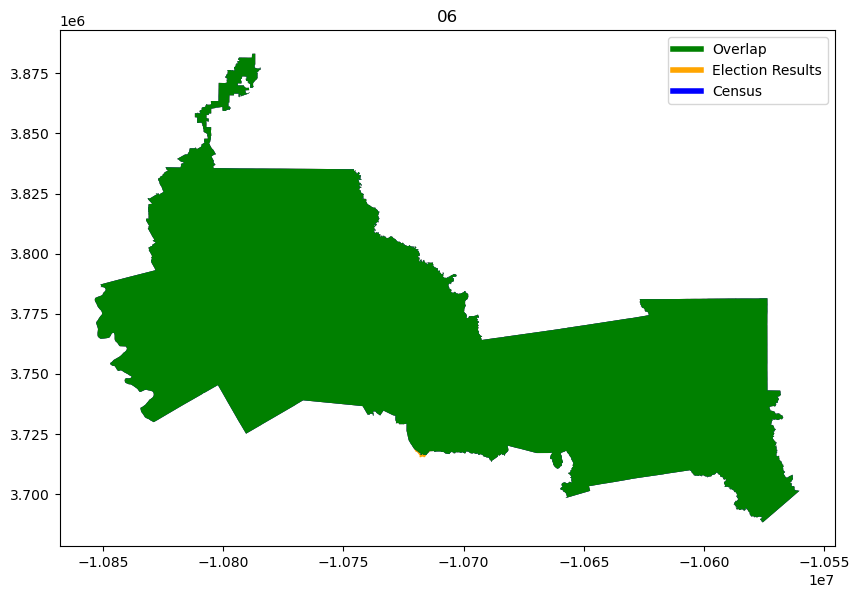

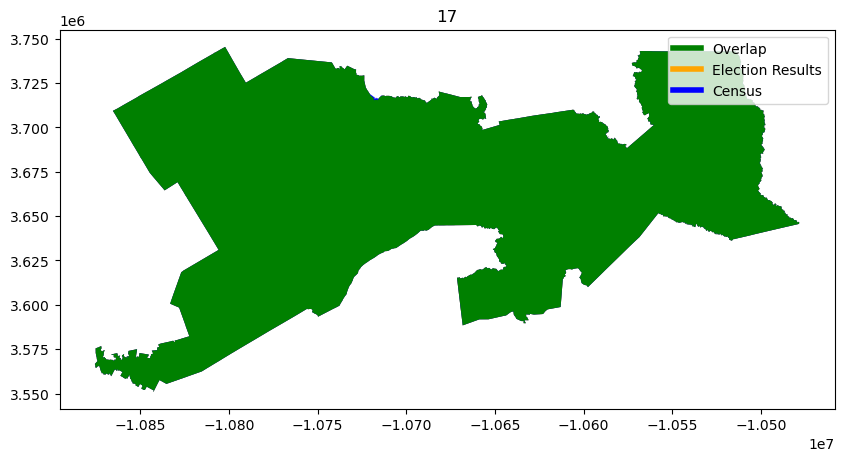

In [234]:
pdv.compare_geometries(filtered_cong_results, tx_cong_districts ,"Election Results", "Census", "CONG_DIST","districts",area_threshold=.1)




In [235]:
pdv.compare_geometries(filtered_sldl_results, tx_sldl_districts ,"Election Results", "Census", "SLDL_DIST","districts",area_threshold=1)


Checking 150 districts for differences of greater than 1 km^2



/Users/peterhorton/Documents/RDH/pber_local/TX_2024/pber_functions_v1.py:368: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)



Scroll down to see plots of any differences

Of the 150 districts:

0 districts w/ a difference of 0 km^2
150 districts w/ a difference between 0 and .1 km^2
0 districts w/ a difference between .1 and .5 km^2
0 districts w/ a difference between .5 and 1 km^2
0 districts w/ a difference between 1 and 2 km^2
0 districts w/ a difference between 2 and 5 km^2
0 districts w/ a difference greater than 5 km^2


In [236]:
pdv.compare_geometries(filtered_sldu_results, tx_sldu_districts ,"Election Results", "Census", "SLDU_DIST","districts",area_threshold=1)


Checking 31 districts for differences of greater than 1 km^2



/Users/peterhorton/Documents/RDH/pber_local/TX_2024/pber_functions_v1.py:368: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  area = float(diff.area/10e6)



Scroll down to see plots of any differences

Of the 31 districts:

0 districts w/ a difference of 0 km^2
29 districts w/ a difference between 0 and .1 km^2
0 districts w/ a difference between .1 and .5 km^2
2 districts w/ a difference between .5 and 1 km^2
0 districts w/ a difference between 1 and 2 km^2
0 districts w/ a difference between 2 and 5 km^2
0 districts w/ a difference greater than 5 km^2


In [237]:
tx_24_cong_tx_vtd.columns

Index(['UNIQUE_ID', 'COUNTYFP', 'County', 'TX_VTD', 'GCON02DFIL', 'GCON02RCRE',
       'GCON03DSRI', 'GCON03RSEL', 'GCON04DCAR', 'GCON04RFAL', 'GCON05DTOR',
       'GCON05RGOO', 'GCON06DLOV', 'GCON06RELL', 'GCON07DFLE', 'GCON07RKAN',
       'GCON08DJON', 'GCON08RLUT', 'GCON10DBOI', 'GCON10LMIL', 'GCON10RMCC',
       'GCON12DHUN', 'GCON12RGOL', 'GCON14DHAR', 'GCON14RWEB', 'GCON15DVAL',
       'GCON15RDEL', 'GCON16DESC', 'GCON16OMON', 'GCON16RARM', 'GCON17DLOR',
       'GCON17RSES', 'GCON18DTUR', 'GCON18ODUN', 'GCON18ODUR', 'GCON18RCEN',
       'GCON19ILEW', 'GCON19LJOH', 'GCON19RARR', 'GCON21DHOO', 'GCON21LKIN',
       'GCON21RROY', 'GCON22DGRE', 'GCON22RNEH', 'GCON23DLIM', 'GCON23RGON',
       'GCON24DEPP', 'GCON24RVAN', 'GCON25OHAG', 'GCON25RWIL', 'GCON26DLIN',
       'GCON26LGRA', 'GCON26RGIL', 'GCON27DLLO', 'GCON27RCLO', 'GCON28DCUE',
       'GCON28RFUR', 'GCON29DGAR', 'GCON29RGAR', 'GCON30DCRO', 'GCON30LJEF',
       'GCON31DWHI', 'GCON31RCAR', 'GCON32DJOH', 'GCON32LHAL', 'GCON32RDA

In [238]:
tx_24_cong_tx_vtd = gp.GeoDataFrame(tx_24_cong_tx_vtd[['UNIQUE_ID', 'COUNTYFP', 'County', 'TX_VTD','CONG_DIST','GCON02DFIL', 'GCON02RCRE',
       'GCON03DSRI', 'GCON03RSEL', 'GCON04DCAR', 'GCON04RFAL', 'GCON05DTOR',
       'GCON05RGOO', 'GCON06DLOV', 'GCON06RELL', 'GCON07DFLE', 'GCON07RKAN',
       'GCON08DJON', 'GCON08RLUT', 'GCON10DBOI', 'GCON10LMIL', 'GCON10RMCC',
       'GCON12DHUN', 'GCON12RGOL', 'GCON14DHAR', 'GCON14RWEB', 'GCON15DVAL',
       'GCON15RDEL', 'GCON16DESC', 'GCON16OMON', 'GCON16RARM', 'GCON17DLOR',
       'GCON17RSES', 'GCON18DTUR', 'GCON18ODUN', 'GCON18ODUR', 'GCON18RCEN',
       'GCON19ILEW', 'GCON19LJOH', 'GCON19RARR', 'GCON21DHOO', 'GCON21LKIN',
       'GCON21RROY', 'GCON22DGRE', 'GCON22RNEH', 'GCON23DLIM', 'GCON23RGON',
       'GCON24DEPP', 'GCON24RVAN', 'GCON25OHAG', 'GCON25RWIL', 'GCON26DLIN',
       'GCON26LGRA', 'GCON26RGIL', 'GCON27DLLO', 'GCON27RCLO', 'GCON28DCUE',
       'GCON28RFUR', 'GCON29DGAR', 'GCON29RGAR', 'GCON30DCRO', 'GCON30LJEF',
       'GCON31DWHI', 'GCON31RCAR', 'GCON32DJOH', 'GCON32LHAL', 'GCON32RDAY',
       'GCON33DVEA', 'GCON33RGIL', 'GCON34DGON', 'GCON34RFLO', 'GCON35DCAS',
       'GCON35RWRI', 'GCON36DSTE', 'GCON36RBAB', 'GCON37DDOG', 'GCON37LALT',
       'GCON37RGAR', 'GCON38DMCD', 'GCON38OAYE', 'GCON38RHUN', 'geometry']])

In [239]:
list(tx_24_cong_tx_vtd_pre_splits.columns)

['UNIQUE_ID',
 'COUNTYFP',
 'County',
 'TX_VTD',
 'G24PREDHAR',
 'G24PREGSTE',
 'G24PRELOLI',
 'G24PREOWRI',
 'G24PRERTRU',
 'G24USSDALL',
 'G24USSLBRO',
 'G24USSOAND',
 'G24USSOROC',
 'G24USSRCRU',
 'GCCA7DMUL',
 'GCCA7RPAR',
 'GCCA8DANY',
 'GCCA8RFIN',
 'GCCAPDTAY',
 'GCCAPRSCH',
 'GCON02DFIL',
 'GCON02RCRE',
 'GCON03DSRI',
 'GCON03RSEL',
 'GCON04DCAR',
 'GCON04RFAL',
 'GCON05DTOR',
 'GCON05RGOO',
 'GCON06DLOV',
 'GCON06RELL',
 'GCON07DFLE',
 'GCON07RKAN',
 'GCON08DJON',
 'GCON08RLUT',
 'GCON10DBOI',
 'GCON10LMIL',
 'GCON10RMCC',
 'GCON12DHUN',
 'GCON12RGOL',
 'GCON14DHAR',
 'GCON14RWEB',
 'GCON15DVAL',
 'GCON15RDEL',
 'GCON16DESC',
 'GCON16OMON',
 'GCON16RARM',
 'GCON17DLOR',
 'GCON17RSES',
 'GCON18DTUR',
 'GCON18ODUN',
 'GCON18ODUR',
 'GCON18RCEN',
 'GCON19ILEW',
 'GCON19LJOH',
 'GCON19RARR',
 'GCON21DHOO',
 'GCON21LKIN',
 'GCON21RROY',
 'GCON22DGRE',
 'GCON22RNEH',
 'GCON23DLIM',
 'GCON23RGON',
 'GCON24DEPP',
 'GCON24RVAN',
 'GCON25OHAG',
 'GCON25RWIL',
 'GCON26DLIN',
 'GCON26LGRA

In [240]:
tx_24_cong_tx_vtd_pre_splits = tx_24_cong_tx_vtd_pre_splits[['UNIQUE_ID',
 'COUNTYFP',
 'County',
 'TX_VTD', 'SLDL_DIST',
 'SLDU_DIST',  'G24PREDHAR',
 'G24PREGSTE',
 'G24PRELOLI',
 'G24PREOWRI',
 'G24PRERTRU',
 'G24USSDALL',
 'G24USSLBRO',
 'G24USSOAND',
 'G24USSOROC',
 'G24USSRCRU',
 'GCCA7DMUL',
 'GCCA7RPAR',
 'GCCA8DANY',
 'GCCA8RFIN',
 'GCCAPDTAY',
 'GCCAPRSCH',
 'GCON02DFIL',
 'GCON02RCRE',
 'GCON03DSRI',
 'GCON03RSEL',
 'GCON04DCAR',
 'GCON04RFAL',
 'GCON05DTOR',
 'GCON05RGOO',
 'GCON06DLOV',
 'GCON06RELL',
 'GCON07DFLE',
 'GCON07RKAN',
 'GCON08DJON',
 'GCON08RLUT',
 'GCON10DBOI',
 'GCON10LMIL',
 'GCON10RMCC',
 'GCON12DHUN',
 'GCON12RGOL',
 'GCON14DHAR',
 'GCON14RWEB',
 'GCON15DVAL',
 'GCON15RDEL',
 'GCON16DESC',
 'GCON16OMON',
 'GCON16RARM',
 'GCON17DLOR',
 'GCON17RSES',
 'GCON18DTUR',
 'GCON18ODUN',
 'GCON18ODUR',
 'GCON18RCEN',
 'GCON19ILEW',
 'GCON19LJOH',
 'GCON19RARR',
 'GCON21DHOO',
 'GCON21LKIN',
 'GCON21RROY',
 'GCON22DGRE',
 'GCON22RNEH',
 'GCON23DLIM',
 'GCON23RGON',
 'GCON24DEPP',
 'GCON24RVAN',
 'GCON25OHAG',
 'GCON25RWIL',
 'GCON26DLIN',
 'GCON26LGRA',
 'GCON26RGIL',
 'GCON27DLLO',
 'GCON27RCLO',
 'GCON28DCUE',
 'GCON28RFUR',
 'GCON29DGAR',
 'GCON29RGAR',
 'GCON30DCRO',
 'GCON30LJEF',
 'GCON31DWHI',
 'GCON31RCAR',
 'GCON32DJOH',
 'GCON32LHAL',
 'GCON32RDAY',
 'GCON33DVEA',
 'GCON33RGIL',
 'GCON34DGON',
 'GCON34RFLO',
 'GCON35DCAS',
 'GCON35RWRI',
 'GCON36DSTE',
 'GCON36RBAB',
 'GCON37DDOG',
 'GCON37LALT',
 'GCON37RGAR',
 'GCON38DMCD',
 'GCON38OAYE',
 'GCON38RHUN',
 'GRRC01DCUL',
 'GRRC01GESP',
 'GRRC01LDUN',
 'GRRC01OMCK',
 'GRRC01RCRA',
 'GSL002DWAS',
 'GSL002RMON',
 'GSL004DBAR',
 'GSL004RBEL',
 'GSL005ONIC',
 'GSL005RHEF',
 'GSL006DGRA',
 'GSL006RALD',
 'GSL007DCOO',
 'GSL007RDEA',
 'GSL008DSAL',
 'GSL008RHAR',
 'GSL010OBRU',
 'GSL010OSCH',
 'GSL010RHAR',
 'GSL012DHOW',
 'GSL012RWHA',
 'GSL013DHUN',
 'GSL013RORR',
 'GSL014DMED',
 'GSL014RDYS',
 'GSL016DMID',
 'GSL016RMET',
 'GSL017DVEN',
 'GSL017RGER',
 'GSL018LSTE',
 'GSL018RHOL',
 'GSL019DHAN',
 'GSL019ISAW',
 'GSL019RTRO',
 'GSL020DWYM',
 'GSL020RWIL',
 'GSL023DMER',
 'GSL023RLEO',
 'GSL025DDAG',
 'GSL025RVAS',
 'GSL026DLEE',
 'GSL026RMOR',
 'GSL027DREY',
 'GSL027RMAX',
 'GSL028DROC',
 'GSL028RGAT',
 'GSL029DBEL',
 'GSL029RBAR',
 'GSL030DBAS',
 'GSL030RLOU',
 'GSL032DMCA',
 'GSL032RHUN',
 'GSL034DORT',
 'GSL034RVIL',
 'GSL037DGRA',
 'GSL037RLOP',
 'GSL039DMAR',
 'GSL039RGAR',
 'GSL041DGUE',
 'GSL041RGUE',
 'GSL043DCAS',
 'GSL043RLOZ',
 'GSL044DNOR',
 'GSL044RSCH',
 'GSL045DZWI',
 'GSL045RMOR',
 'GSL046DCOL',
 'GSL046RKOS',
 'GSL047DGOO',
 'GSL047RFIR',
 'GSL048DHOW',
 'GSL048LMCC',
 'GSL052DBIR',
 'GSL052RHAR',
 'GSL053DHER',
 'GSL053LHOL',
 'GSL053RVIR',
 'GSL054DRIC',
 'GSL054RBUC',
 'GSL055DLEE',
 'GSL055RHIC',
 'GSL056DSHA',
 'GSL056RCUR',
 'GSL057DJOH',
 'GSL057LHAM',
 'GSL057RHAY',
 'GSL058LWIN',
 'GSL058RKER',
 'GSL059DBOH',
 'GSL059RSLA',
 'GSL061DADA',
 'GSL061RRIC',
 'GSL062DDRA',
 'GSL062RLUT',
 'GSL063DBEC',
 'GSL063RBUM',
 'GSL064DBRE',
 'GSL064RHOP',
 'GSL065DDEB',
 'GSL065RLIT',
 'GSL066DCAR',
 'GSL066RSHA',
 'GSL067DWAS',
 'GSL067RLEA',
 'GSL068DSWA',
 'GSL068RSPI',
 'GSL069DCOP',
 'GSL069RFRA',
 'GSL070DPLE',
 'GSL070RKIN',
 'GSL071DGOO',
 'GSL071RLAM',
 'GSL073DDUV',
 'GSL073RISA',
 'GSL074DMOR',
 'GSL074RGAR',
 'GSL076DLAL',
 'GSL076RSIM',
 'GSL080DCAS',
 'GSL080RMCL',
 'GSL082DSCH',
 'GSL082RCRA',
 'GSL084DLOP',
 'GSL084RTEP',
 'GSL087DGAS',
 'GSL087OMCG',
 'GSL087RFAI',
 'GSL089DEVA',
 'GSL089RNOB',
 'GSL093DBOJ',
 'GSL093RSCH',
 'GSL094DWIL',
 'GSL094RTIN',
 'GSL096DTUR',
 'GSL096RCOO',
 'GSL097DWAL',
 'GSL097RMCQ',
 'GSL098DWHI',
 'GSL098RCAP',
 'GSL099DCOF',
 'GSL099RGER',
 'GSL101DTUR',
 'GSL101RBUR',
 'GSL105DMEZ',
 'GSL105RCAN',
 'GSL106DJOH',
 'GSL106RPAT',
 'GSL108DGIN',
 'GSL108RMEY',
 'GSL112DBIS',
 'GSL112RBUT',
 'GSL113DBOW',
 'GSL113RSTA',
 'GSL114DBRY',
 'GSL114RRAM',
 'GSL115DGAR',
 'GSL115RJUN',
 'GSL116DMAR',
 'GSL116RCRA',
 'GSL117DCOR',
 'GSL117RMOS',
 'GSL118DCAR',
 'GSL118RLUJ',
 'GSL119DCAM',
 'GSL119RGRA',
 'GSL121DSWI',
 'GSL121RLAH',
 'GSL122DGEA',
 'GSL122RDOR',
 'GSL124DGAR',
 'GSL124RSOT',
 'GSL126OSMI',
 'GSL126RHAR',
 'GSL127DLEH',
 'GSL127RCUN',
 'GSL128DCRE',
 'GSL128LHAG',
 'GSL128RCAI',
 'GSL129DPET',
 'GSL129RPAU',
 'GSL130DROB',
 'GSL130ROLI',
 'GSL132DWES',
 'GSL132RSCH',
 'GSL134DJOH',
 'GSL134RDOU',
 'GSL136DBUC',
 'GSL136RSAL',
 'GSL137DWU',
 'GSL137LSHA',
 'GSL138DMOR',
 'GSL138RHUL',
 'GSL146DSIM',
 'GSL146RYOR',
 'GSL147DJON',
 'GSL147RGUT',
 'GSL148DMOR',
 'GSL148RSMI',
 'GSL149DVO',
 'GSL149RTRU',
 'GSL150DJIM',
 'GSL150RSWA',
 'GSSC02DJON',
 'GSSC02RBLA',
 'GSSC04DWEE',
 'GSSC04RDEV',
 'GSSC06DGOL',
 'GSSC06LROB',
 'GSSC06RBLA',
 'GSU06DALV',
 'GSU06RFIE',
 'GSU07DGWI',
 'GSU07RBET',
 'GSU08DMEL',
 'GSU08RPAX',
 'GSU10DMOR',
 'GSU10RKIN',
 'GSU12DDRA',
 'GSU12RPAR',
 'GSU15DCOO',
 'GSU15RTRA',
 'GSU17DCHE',
 'GSU17RHUF',
 'GSU25DFOX',
 'GSU25RCAM',
 'GSU27DLAM',
 'GSU27GVAR',
 'GSU27RHIN',
 'GSU30DFRE',
 'GSU30RHAG',
 'geometry',]]

In [241]:
import os

if not os.path.exists("./tx_2024_gen_tx_vtd"):
    os.mkdir("./tx_2024_gen_tx_vtd")

tx_24_cong_tx_vtd_pre_splits.to_file("./tx_2024_gen_tx_vtd/tx_2024_gen_all_tx_vtd.shp", index = False)
tx_24_cong_tx_vtd.to_file("./tx_2024_gen_tx_vtd/tx_2024_gen_cong_tx_vtd.shp", index = False)

In [242]:
import shutil

In [243]:
shutil.make_archive("./tx_2024_gen_tx_vtd", "zip", "./tx_2024_gen_tx_vtd")

'/Users/peterhorton/Documents/RDH/pber_local/TX_2024/tx_2024_gen_tx_vtd.zip'